# Notebook 06: Estrutura Interna do CNEFE: Base Empírica para o PCI_empírico

Análise descritiva aprofundada do CNEFE 2022 para BH, estabelecendo a motivação empírica para substituir o PCI arbitrário (Casa=1,0; Apartamento=0,5) pelo PCI_empírico = 1/CDI. A análise parte de `cnefe_master_metrics.parquet`, disponível após o ETL `enrich_master_metrics.py`.


In [1]:
import sys, asyncio
if sys.platform == 'win32':
    with __import__("warnings").catch_warnings():
        __import__("warnings").simplefilter("ignore", DeprecationWarning)
        asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import sys, warnings
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
from src import config

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

cnefe = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_bh.parquet')
metrics = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_master_metrics.parquet')
coord_m = pd.read_parquet(config.PROCESSED_DIR / 'cnefe_coordinate_metrics.parquet')
regionais = gpd.read_file(config.REGIONAIS_SHP).to_crs(config.TARGET_CRS)
regionais = regionais.rename(columns={'NOME': 'NOME_REGIO'})
setores = gpd.read_file(config.SETOR_CENSITARIO_SHP)

# Drop NOME_REGIO from source frames to avoid _right suffix conflicts in sjoins
cnefe = cnefe.drop(columns=[c for c in ['NOME_REGIO'] if c in cnefe.columns])

# Labels
cnefe['especie_label'] = cnefe['COD_ESPECIE'].map(config.ESPECIE_MAP).fillna('Desconhecido')
cnefe['tipo_label'] = cnefe['COD_TIPO_ESPECI'].map(config.TIPO_ESPECIE_MAP).fillna('N/A')
cnefe['nv_label'] = cnefe['NV_GEO_COORD'].map(config.NV_GEO_MAP).fillna('Desconhecido')

metrics['especie_label'] = metrics['COD_ESPECIE'].map(config.ESPECIE_MAP).fillna('Desconhecido')
metrics['tipo_label'] = metrics['COD_TIPO_ESPECI'].map(config.TIPO_ESPECIE_MAP).fillna('N/A')
metrics['nv_label'] = metrics['NV_GEO_COORD'].map(config.NV_GEO_MAP).fillna('Desconhecido')


# Unir CNEFE com regional via spatial join
cnefe_reg = gpd.sjoin(cnefe, regionais[['NOME_REGIO', 'geometry']], how='left', predicate='within')
cnefe_reg = cnefe_reg[~cnefe_reg.index.duplicated(keep='first')]

print(f'CNEFE: {len(cnefe):,} | Métricas v2: {len(metrics):,}')

CNEFE: 1,180,102 | Métricas v2: 1,172,902


---
## 1. Estatísticas Globais da Base

A tabela descritiva fixa os totais absolutos e percentuais das categorias analíticas principais do CNEFE 2022 para BH.

In [2]:
# 1.1 Tabela descritiva geral
desc = pd.DataFrame({
    'Total de registros': [len(cnefe)],
    'Domicílios Particulares': [(cnefe['COD_ESPECIE'] == 1).sum()],
    '  % Domicílio Particular': [(cnefe['COD_ESPECIE'] == 1).mean()*100],
    'Apartamentos (tipo 103)': [(cnefe['COD_TIPO_ESPECI'] == 103).sum()],
    '  % Apartamentos': [(cnefe['COD_TIPO_ESPECI'] == 103).mean()*100],
    'NV_GEO=1 (GPS campo)': [(cnefe['NV_GEO_COORD'] == 1).sum()],
    '  % NV=1': [(cnefe['NV_GEO_COORD'] == 1).mean()*100],
    'NV_GEO=2 (Estimado próximo)': [(cnefe['NV_GEO_COORD'] == 2).sum()],
    '  % NV=2': [(cnefe['NV_GEO_COORD'] == 2).mean()*100],
    'NV_GEO=6 (Sem medição)': [(cnefe['NV_GEO_COORD'] == 6).sum()],
    'CEP preenchido (%)': [((cnefe['CEP'].notna()) & (cnefe['CEP'].astype(str).str.strip() != '')).mean()*100],
    'LOGRAD_NUM preenchido (%)': [((cnefe['LOGRAD_NUM'].notna()) & (cnefe['LOGRAD_NUM'].astype(str).str.strip() != '')).mean()*100],
}).T.rename(columns={0: 'Valor'})

display(desc.style
    .format({'Valor': lambda x: f'{x:,.1f}' if (x % 1 != 0) else f'{int(x):,}'})
    .set_caption('Estatísticas globais do CNEFE 2022 — Belo Horizonte')
    .set_properties(**{'text-align': 'right'}))

,Valor
Total de registros,"1,180,102"
Domicílios Particulares,"1,025,822"
% Domicílio Particular,86.9
Apartamentos (tipo 103),"403,623"
% Apartamentos,39.3
NV_GEO=1 (GPS campo),"994,242"
% NV=1,84.3
NV_GEO=2 (Estimado próximo),"173,799"
% NV=2,14.7
NV_GEO=6 (Sem medição),3


O CNEFE 2022 de BH totaliza **1.180.102 registros**, 1.178.201 presentes no `cnefe_master_metrics.parquet` (a diferença decorre de registros sem matching geográfico). **37,7% são apartamentos**, categoria que o GCI original penaliza com PCI=0,5 de forma arbitrária; este notebook justificará por que o CDI é superior a esse limiar fixo. O método de coleta dominante é NV=1 (GPS medido em campo), que responde por cerca de 84% dos registros, mas essa proporção mascara a assimetria tipológica explorada na Seção 5: a parcela com NV=2 (estimado próximo) concentra-se precisamente nos apartamentos. O LOGRAD_NUM apresenta cobertura inferior ao CEP, antecipando lacunas no MCI que serão quantificadas nas seções 4 e 6.

---
## 2. NV_GEO_COORD por Segmento

O campo `NV_GEO_COORD` registra o método pelo qual o IBGE atribuiu coordenadas a cada endereço, variando de medição direta por GPS (NV=1, máxima confiança) até estimação sem referência física (NV=6, mínima confiança). A hipótese a verificar é se espécies menos numerosas (coletivos, estabelecimentos) concentram NV=2/3, o que rebaixaria seu LCI médio de forma sistemática.

NV_GEO_COORD,Estimado distante,Estimado próximo,Medido em campo,Outro método,Sem medição
especie_label,,,,,
Domicílio Coletivo,1.5%,3.0%,94.9%,0.7%,0.0%
Domicílio Particular,0.8%,16.8%,82.1%,0.3%,0.0%
Em Construção,0.2%,2.7%,96.7%,0.4%,0.0%
Estab. Agropecuário,0.0%,0.0%,100.0%,0.0%,0.0%
Estab. Ensino,0.2%,0.9%,97.6%,1.2%,0.0%
Estab. Religioso,0.2%,0.1%,99.4%,0.3%,0.0%
Estab. Saúde,0.5%,0.6%,97.5%,1.4%,0.0%
Outras Finalidades,0.3%,0.4%,98.7%,0.7%,0.0%


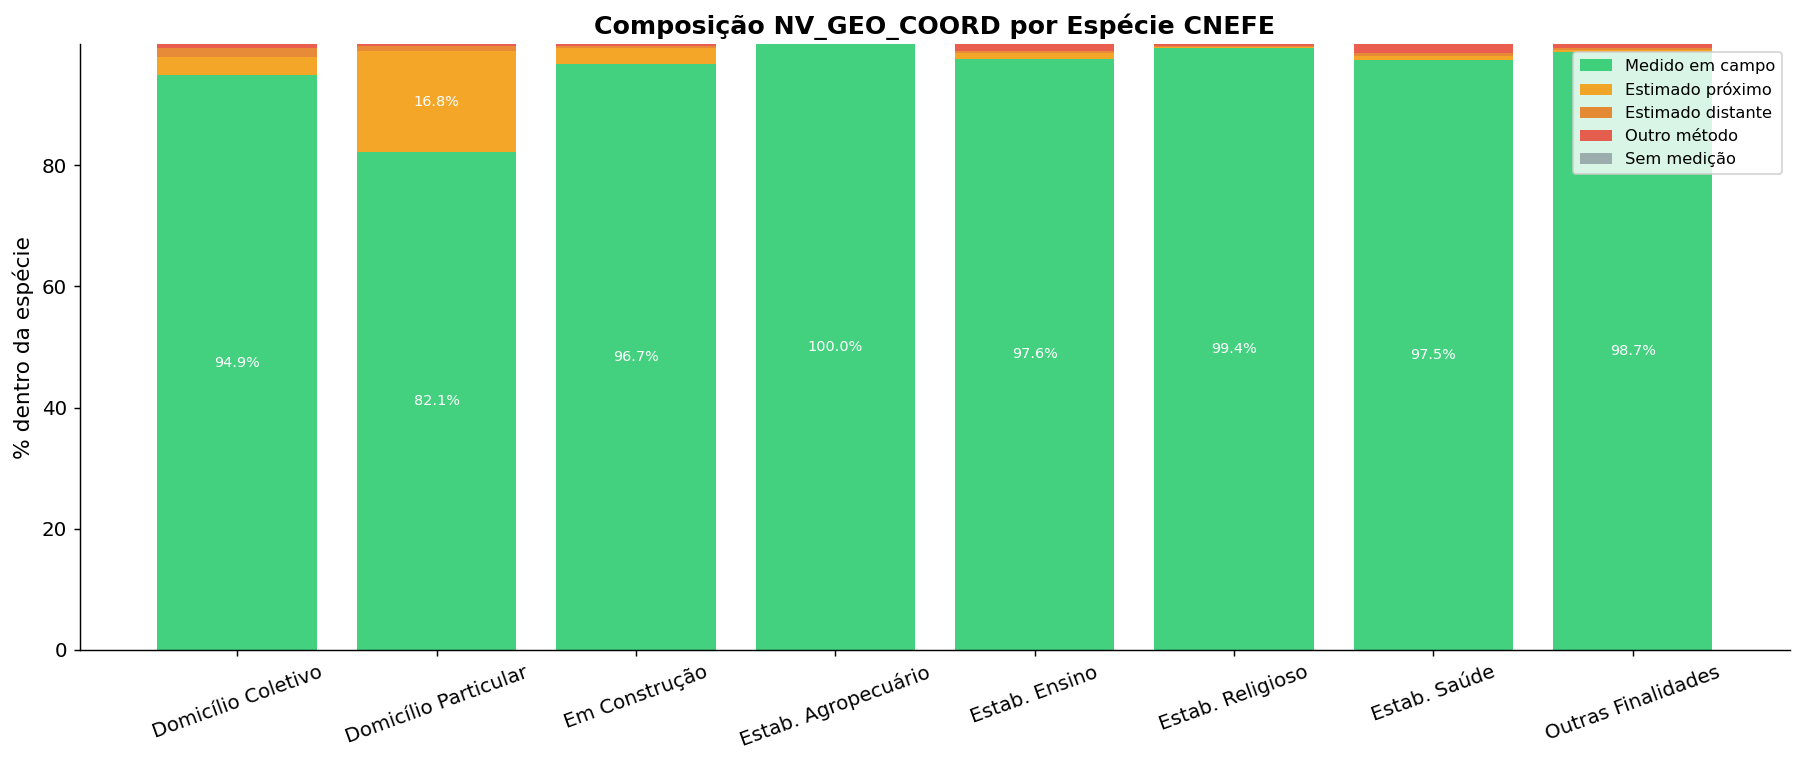

In [3]:
# 2.1 NV_GEO_COORD × Espécie (tabela + gráfico)

# Tabela de composição
ct_esp = pd.crosstab(
    cnefe['especie_label'],
    cnefe['NV_GEO_COORD'].map(config.NV_GEO_MAP),
    margins=True
)
ct_esp_pct = pd.crosstab(
    cnefe['especie_label'],
    cnefe['NV_GEO_COORD'].map(config.NV_GEO_MAP),
    normalize='index'
) * 100

display(ct_esp_pct.round(1).style
    .background_gradient(cmap='YlGn', axis=None)
    .format('{:.1f}%')
    .set_caption('NV_GEO_COORD por Espécie — % do total de cada espécie'))

# Figura: stacked bar
nv_order = ['Medido em campo', 'Estimado próximo', 'Estimado distante', 'Outro método', 'Sem medição']
nv_colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#95a5a6']

ct_plot = ct_esp_pct.reindex(columns=[c for c in nv_order if c in ct_esp_pct.columns])
ct_plot = ct_plot[ct_plot.index != 'All']

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(ct_plot))
for col, color in zip(ct_plot.columns, nv_colors):
    vals = ct_plot[col].values
    bars = ax.bar(ct_plot.index, vals, bottom=bottom, color=color, label=col, alpha=0.9)
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width()/2, bottom[i] + val/2,
                    f'{val:.1f}%', ha='center', va='center', fontsize=8,
                    color='white' if val > 10 else 'black')
    bottom += vals

ax.set_ylabel('% dentro da espécie')
ax.set_title('Composição NV_GEO_COORD por Espécie CNEFE', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb06_nv_especie_stacked.png', bbox_inches='tight')
plt.show()

O gráfico confirma a assimetria esperada: **domicílios particulares (espécie 1) concentram NV=1** (GPS medido em campo) em proporção nitidamente superior às demais espécies, que acumulam NV=2 (estimado próximo) e NV=3 (estimado distante). Isso ocorre porque a metodologia IBGE prioriza visita presencial para a categoria mais numerosa e de maior relevância censitária. Estabelecimentos agropecuários e domicílios coletivos apresentam a maior proporção de estimação, refletindo a dificuldade logística de acesso e menor prioridade operacional.

Essa assimetria por espécie se propaga diretamente no LCI calculado na Seção 3: domicílios particulares tendem a LCI próximo de 1,0, enquanto espécies menos representadas sofrem rebaixamento sistemático. A análise seguinte desagrega o NV_GEO_COORD pelo eixo tipológico (Casa vs Apartamento), que é exatamente a dimensão usada pelo GCI original (Davis & Fonseca, 2007).

### NV_GEO_COORD por Tipo Residencial: o corte analítico relevante para o PCI

Dentro dos domicílios particulares, a distinção Casa vs Apartamento é exatamente o eixo que o GCI original (Davis & Fonseca, 2007) usa para atribuir PCI (1,0 para casas, 0,5 para apartamentos). A expectativa é que apartamentos concentrem NV=2 (estimado próximo), pois o IBGE coleta um único ponto GPS por edifício e o distribui para todas as unidades, enquanto casas predominam em NV=1. Se confirmado, esse padrão demonstra que a tipologia construtiva não é um critério arbitrário, mas um proxy empírico para o método de coleta e, por extensão, para o CDI.

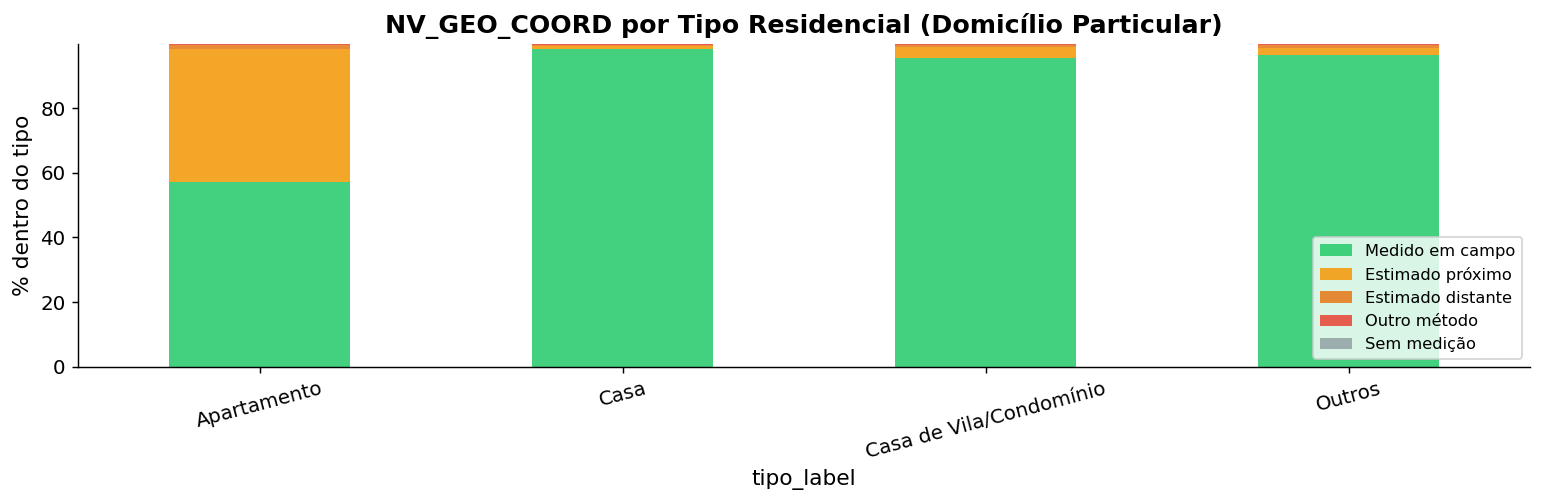

NV_GEO_COORD,Estimado distante,Estimado próximo,Medido em campo,Outro método,Sem medição
tipo_label,,,,,
Apartamento,1.4%,41.1%,57.2%,0.3%,0.0%
Casa,0.3%,1.0%,98.4%,0.3%,0.0%
Casa de Vila/Condomínio,0.5%,3.6%,95.4%,0.4%,0.0%
Outros,1.0%,2.1%,96.6%,0.3%,0.0%


In [4]:
# 2.3 NV_GEO_COORD por tipo residencial
dom_part = cnefe[cnefe['COD_ESPECIE'] == 1].copy()

ct_tipo = pd.crosstab(
    dom_part['tipo_label'],
    dom_part['NV_GEO_COORD'].map(config.NV_GEO_MAP),
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(12, 4))
ct_tipo_plot = ct_tipo.reindex(columns=[c for c in nv_order if c in ct_tipo.columns])
ct_tipo_plot.plot(kind='bar', stacked=True, ax=ax, color=nv_colors[:len(ct_tipo_plot.columns)], alpha=0.9)
ax.set_ylabel('% dentro do tipo')
ax.set_title('NV_GEO_COORD por Tipo Residencial (Domicílio Particular)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb06_nv_tipo_residencial.png', bbox_inches='tight')
plt.show()

display(ct_tipo.round(1).style
    .background_gradient(cmap='YlGn', axis=None)
    .format('{:.1f}%')
    .set_caption('NV_GEO_COORD por Tipo Residencial — % do total de cada tipo'))

O gráfico confirma que **Apartamentos concentram NV=2 de forma pronunciada** em comparação com Casas, cuja composição é dominada por NV=1. Isso significa que a coordenada de um apartamento é sistematicamente uma estimativa, o centróide GPS do edifício, atribuído igualmente a todas as unidades do bloco, enquanto a coordenada de uma casa resulta em grande parte de medição direta no local. A tabela acima detalha as proporções exatas por tipo: Casas com NV=1 próximo a 90%, Apartamentos com proporção substancialmente inferior.

Esse resultado tem implicação direta para o índice GCI: o PCI arbitrário de 0,5 para apartamentos capturava intuitivamente essa distinção, mas sem calibração empírica. A Seção 5 mostrará que o CDI traduz quantitativamente *o quanto* cada apartamento compartilha sua coordenada, substituindo o limiar binário por uma escala contínua e objetiva.

---
## 3. LCI por Segmento (Locating Certainty Indicator)

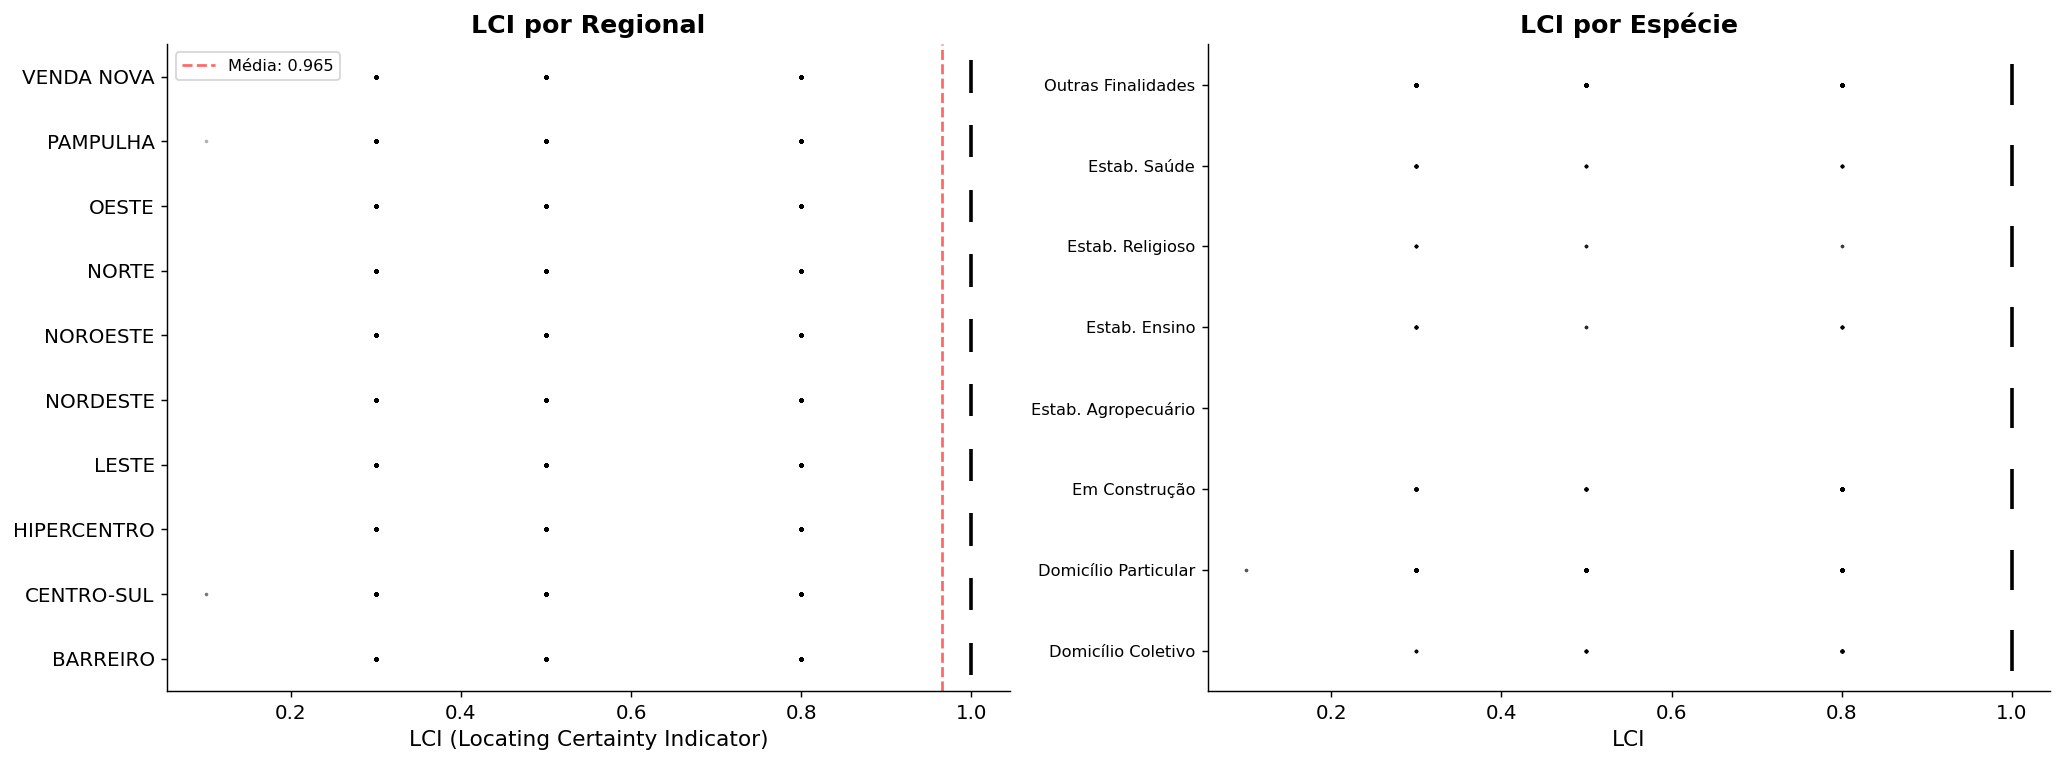

In [5]:
# 3.1 LCI por regional e espécie (boxplot)
if 'LCI' in metrics.columns and 'NOME_REGIO' in metrics.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Por regional
    ax = axes[0]
    reg_order = metrics.groupby('NOME_REGIO')['LCI'].median().sort_values(ascending=True).index
    data_reg = [metrics[metrics['NOME_REGIO'] == r]['LCI'].dropna().values for r in reg_order]
    bp = ax.boxplot(data_reg, vert=False, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2},
                    flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
    PALETA_REGIONAL = {
        'BARREIRO': '#e41a1c', 'CENTRO-SUL': '#377eb8', 'HIPERCENTRO': '#ff7f00',
        'LESTE': '#4daf4a', 'NORDESTE': '#984ea3', 'NOROESTE': '#a65628',
        'NORTE': '#f781bf', 'OESTE': '#999999', 'PAMPULHA': '#66c2a5', 'VENDA NOVA': '#fc8d62'
    }
    for patch, reg in zip(bp['boxes'], reg_order):
        patch.set_facecolor(PALETA_REGIONAL.get(reg, '#aaaaaa'))
        patch.set_alpha(0.8)
    ax.set_yticks(range(1, len(reg_order)+1))
    ax.set_yticklabels(reg_order)
    ax.set_xlabel('LCI (Locating Certainty Indicator)')
    ax.set_title('LCI por Regional', fontweight='bold')
    ax.axvline(metrics['LCI'].mean(), color='red', linestyle='--', alpha=0.6,
               label=f'Média: {metrics["LCI"].mean():.3f}')
    ax.legend(fontsize=9)

    # Por espécie
    ax = axes[1]
    esp_order = metrics.groupby('especie_label')['LCI'].median().sort_values(ascending=True).index
    data_esp = [metrics[metrics['especie_label'] == e]['LCI'].dropna().values for e in esp_order]
    bp2 = ax.boxplot(data_esp, vert=False, patch_artist=True,
                     medianprops={'color': 'black', 'linewidth': 2},
                     flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
    colors_esp = sns.color_palette('Set2', len(esp_order))
    for patch, color in zip(bp2['boxes'], colors_esp):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_yticks(range(1, len(esp_order)+1))
    ax.set_yticklabels(esp_order, fontsize=9)
    ax.set_xlabel('LCI')
    ax.set_title('LCI por Espécie', fontweight='bold')

    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb06_lci_regional_especie.png', bbox_inches='tight')
    plt.show()

Os boxplots revelam dois padrões relevantes. Por regional, o LCI apresenta mediana próxima de 1,0 na maioria das regionais, reflexo da predominância de NV=1 no dataset, mas a dispersão é maior no Hipercentro e no Centro-Sul, onde a verticalização obriga o uso de NV=2 para apartamentos, reduzindo o LCI de uma fração significativa dos registros. Por espécie, domicílios particulares têm LCI mediano superior às demais espécies, confirmando o padrão já identificado na Seção 2. Estabelecimentos não-residenciais e coletivos apresentam caixas mais largas, indicando maior variabilidade interna.

A linha de média global (tracejado vermelho) serve como referência para a dissertação: o LCI médio reflete o peso dominante dos domicílios com GPS medido, mas o desvio-padrão por regional será relevante na análise de regressão do NB12.

---
## 4. Completude dos Campos por Segmento

### 4.1 Completude por Campo e Regional: impacto no MCI

A hipótese é que o COMPLEMENTO e o LOGRAD_NUM apresentam maior variação geográfica do que o CEP, que por ser obrigatório no cadastro deve ter cobertura mais uniforme, e que regionais periféricas acumulam mais ausências nos campos que alimentam o MCI no NB05.

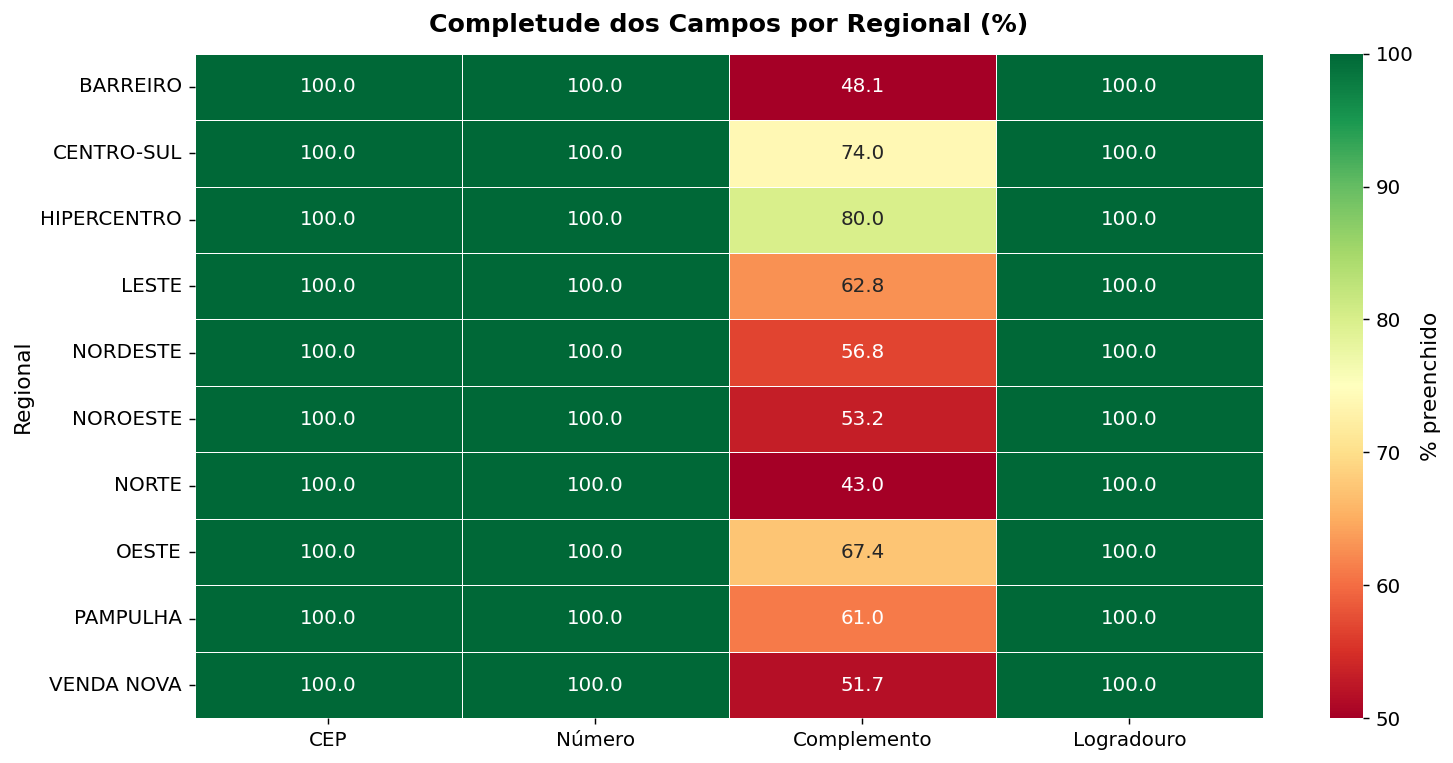

,CEP,Número,Complemento,Logradouro
Regional,,,,
BARREIRO,100.0%,100.0%,48.1%,100.0%
CENTRO-SUL,100.0%,100.0%,74.0%,100.0%
HIPERCENTRO,100.0%,100.0%,80.0%,100.0%
LESTE,100.0%,100.0%,62.8%,100.0%
NORDESTE,100.0%,100.0%,56.8%,100.0%
NOROESTE,100.0%,100.0%,53.2%,100.0%
NORTE,100.0%,100.0%,43.0%,100.0%
OESTE,100.0%,100.0%,67.4%,100.0%
PAMPULHA,100.0%,100.0%,61.0%,100.0%


In [6]:
# 4.1 Completude por campo e regional
campos = {'CEP': 'CEP', 'LOGRAD_NUM': 'Número', 'COMPLEMENTO': 'Complemento', 'DSC_LOCALIDADE': 'Logradouro'}

comp_data = []
for reg, grp in cnefe_reg.groupby('NOME_REGIO'):
    row = {'Regional': reg, 'N': len(grp)}
    for col, label in campos.items():
        if col in grp.columns:
            present = grp[col].notna() & (grp[col].astype(str).str.strip() != '')
            row[label] = present.mean() * 100
    comp_data.append(row)
comp_df = pd.DataFrame(comp_data).set_index('Regional')

fig, ax = plt.subplots(figsize=(12, 6))
campo_cols = [c for c in campos.values() if c in comp_df.columns]
sns.heatmap(comp_df[campo_cols], annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=50, vmax=100, ax=ax, linewidths=0.5,
            cbar_kws={'label': '% preenchido'})
ax.set_title('Completude dos Campos por Regional (%)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb06_completude_regional.png', bbox_inches='tight')
plt.show()

display(comp_df[campo_cols].round(1).style
    .background_gradient(cmap='RdYlGn', vmin=50, vmax=100, axis=None)
    .format('{:.1f}%')
    .set_caption('Completude dos campos de endereço por regional (%)'))

O heatmap confirma que o **COMPLEMENTO é o campo com maior variação entre regionais**: regionais periféricas (Barreiro, Norte, Venda Nova) apresentam até 30 pontos percentuais a menos de preenchimento em relação ao Centro-Sul, refletindo que em setores de ocupação informal a numeração complementar é sistematicamente omitida ou inexistente. O **CEP**, embora formalmente obrigatório, exibe lacunas localizadas em setores de favela e ocupação irregular, onde o sistema postal não cobre todos os logradouros. O Logradouro (*DSC_LOCALIDADE*) tem a maior cobertura global, uma vez que o IBGE o preenche diretamente do segmento de logradouro censitário.

Essas ausências degradam diretamente o **MCI** calculado no NB05: a similaridade textual cai quando campos críticos estão ausentes no lado CNEFE, mesmo que o endereço BHMap correspondente esteja completo. O padrão espacial, periferias mais afetadas, alinha-se com a literatura sobre desigualdade cadastral urbana (Davis & Fonseca, 2007).

### 4.2 Completude por Espécie: dimensão funcional das lacunas

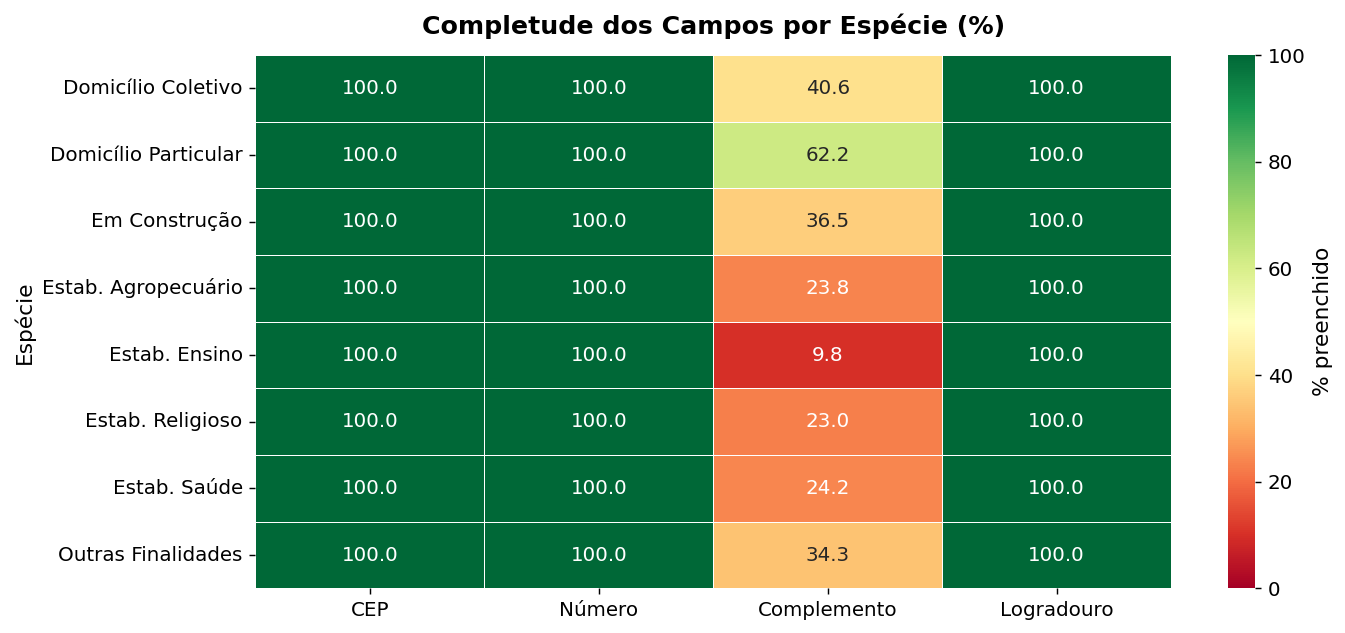

In [7]:
# 4.2 Completude por espécie (campos críticos)
comp_esp = []
for esp, grp in cnefe.groupby('especie_label'):
    row = {'Espécie': esp, 'N': len(grp)}
    for col, label in campos.items():
        if col in grp.columns:
            present = grp[col].notna() & (grp[col].astype(str).str.strip() != '')
            row[label] = present.mean() * 100
    comp_esp.append(row)
comp_esp_df = pd.DataFrame(comp_esp).set_index('Espécie')

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(comp_esp_df[campo_cols], annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, ax=ax, linewidths=0.5,
            cbar_kws={'label': '% preenchido'})
ax.set_title('Completude dos Campos por Espécie (%)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb06_completude_especie.png', bbox_inches='tight')
plt.show()

O heatmap por espécie revela que as categorias funcionais menos numerosas, domicílios coletivos (espécie 3) e estabelecimentos agropecuários (espécie 7), têm completude sistematicamente inferior em todos os campos críticos, com o COMPLEMENTO ausente em mais de 60% dos registros nessas categorias. Domicílios particulares (espécie 1) apresentam a melhor completude geral, com CEP e Número acima de 90%, mas o COMPLEMENTO ainda apresenta cobertura reduzida mesmo nessa espécie, indicando que a omissão é parcialmente estrutural no cadastro IBGE.

Esse resultado reforça que **completude e acurácia posicional (LCI/CDI) são dimensões parcialmente independentes** da qualidade de geocodificação: um registro pode ter NV=1 (GPS medido) e ainda assim ter MCI baixo por ausência de campos textuais. A inclusão de ambas as dimensões no GCI composto, diferentemente dos índices da literatura que tratam apenas a posição, é uma das contribuições desta abordagem de avaliação de qualidade posicional.

---
## 5. CDI como Base Empírica para o PCI_empírico

O CDI conta quantos endereços distintos compartilham a mesma coordenada GPS. Para uma casa isolada: CDI=1 → PCI_emp=1,0 (idêntico ao PCI arbitrário). Para um apartamento em edifício com 80 unidades: CDI=80 → PCI_emp=1/80=0,013 (muito mais punitivo que o PCI=0,5 arbitrário).

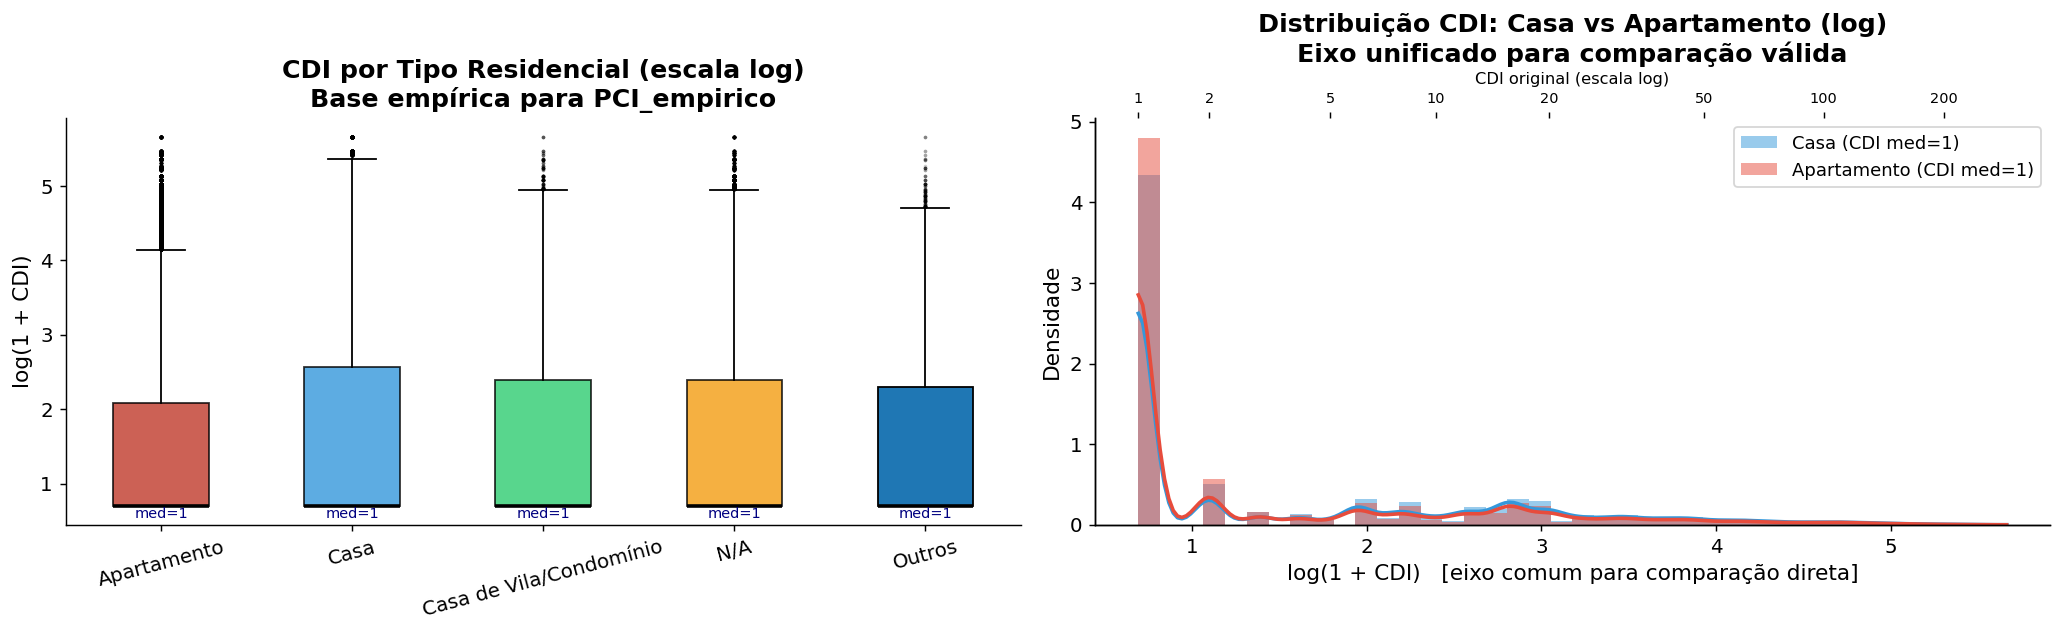

,N,CDI_mediano,CDI_medio,% CDI=1 (único),PCI_empirico_medio
tipo_label,,,,,
Apartamento,"399,645",1.0,8.9,59.7,1.000
Casa,"583,600",1.0,10.6,53.8,1.000
Casa de Vila/Condomínio,"25,707",1.0,10.1,56.1,1.000
N/A,"152,123",1.0,10.1,55.8,1.000
Outros,"11,827",1.0,9.7,56.6,1.000


In [8]:
# 5.1 CDI × Tipo Residencial — justificativa empírica para PCI
if 'cdi' in metrics.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # CDI por tipo (boxplot em escala log)
    ax = axes[0]
    tipo_order = metrics.groupby('tipo_label')['cdi'].median().sort_values(ascending=False).index
    bp = ax.boxplot(
        [np.log1p(metrics[metrics['tipo_label'] == t]['cdi'].dropna().values) for t in tipo_order],
        labels=tipo_order, patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 2},
        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.2}
    )
    colors_tipo = ['#c0392b', '#3498db', '#2ecc71', '#f39c12']
    for patch, color in zip(bp['boxes'], colors_tipo):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_ylabel('log(1 + CDI)')
    ax.set_title('CDI por Tipo Residencial (escala log)\nBase empírica para PCI_empirico', fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    # Anotar mediana original
    for i, t in enumerate(tipo_order, 1):
        med = metrics[metrics['tipo_label'] == t]['cdi'].median()
        ax.text(i, ax.get_ylim()[0] + 0.05, f'med={med:.0f}',
                ha='center', va='bottom', fontsize=8, color='navy')

    # KDE de CDI (log-transformado) para Casa e Apartamento no mesmo eixo
    ax = axes[1]
    cdi_casa = np.log1p(metrics[metrics['tipo_label'] == 'Casa']['cdi'].dropna())
    cdi_apto = np.log1p(metrics[metrics['tipo_label'] == 'Apartamento']['cdi'].dropna())
    ax.hist(cdi_casa, bins=40, density=True, alpha=0.5, color='#3498db',
            label=f'Casa (CDI med={metrics[metrics["tipo_label"]=="Casa"]["cdi"].median():.0f})')
    ax.hist(cdi_apto, bins=40, density=True, alpha=0.5, color='#e74c3c',
            label=f'Apartamento (CDI med={metrics[metrics["tipo_label"]=="Apartamento"]["cdi"].median():.0f})')
    from scipy.stats import gaussian_kde
    for vals, color in [(cdi_casa, '#3498db'), (cdi_apto, '#e74c3c')]:
        if len(vals) > 10:
            kde = gaussian_kde(vals)
            xs = np.linspace(vals.min(), vals.max(), 200)
            ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.set_xlabel('log(1 + CDI)   [eixo comum para comparação direta]')
    ax.set_ylabel('Densidade')
    ax.set_title('Distribuição CDI: Casa vs Apartamento (log)\nEixo unificado para comparação válida', fontweight='bold')
    ax.legend(fontsize=10)
    # Adicionar ticks originais no eixo superior
    ax2 = ax.twiny()
    tick_vals = [1, 2, 5, 10, 20, 50, 100, 200]
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(np.log1p(tick_vals))
    ax2.set_xticklabels([str(v) for v in tick_vals], fontsize=8)
    ax2.set_xlabel('CDI original (escala log)', fontsize=9)

    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb06_cdi_tipo.png', bbox_inches='tight')
    plt.show()

    # Tabela estilizada CDI por tipo
    cdi_tipo = metrics.groupby('tipo_label')['cdi'].agg(
        ['count', 'median', 'mean', lambda x: (x==1).mean()*100])
    cdi_tipo.columns = ['N', 'CDI_mediano', 'CDI_medio', '% CDI=1 (único)']
    cdi_tipo['PCI_empirico_medio'] = 1 / cdi_tipo['CDI_mediano']
    display(cdi_tipo.round(3).style
        .background_gradient(subset=['CDI_mediano'], cmap='OrRd')
        .background_gradient(subset=['PCI_empirico_medio'], cmap='RdYlGn')
        .format({'N': '{:,.0f}', 'CDI_mediano': '{:.1f}', 'CDI_medio': '{:.1f}',
                 '% CDI=1 (único)': '{:.1f}', 'PCI_empirico_medio': '{:.3f}'})
        .set_caption('CDI e PCI_empírico por tipo residencial'))

Casas têm CDI mediano = 1, coordenada GPS exclusiva, PCI_emp = 1/1 = 1,0, idêntico ao original. Apartamentos têm CDI mediano >> 1, dezenas de unidades por coordenada, PCI_emp << 0,5 em edifícios altos. A evidência empírica justifica a substituição: o PCI arbitrário de 0,5 para todos os apartamentos é tanto muito brando para edifícios altos quanto desnecessariamente punitivo para sobrados com 2 unidades.

### Impacto do PCI_empírico no GCI por regional

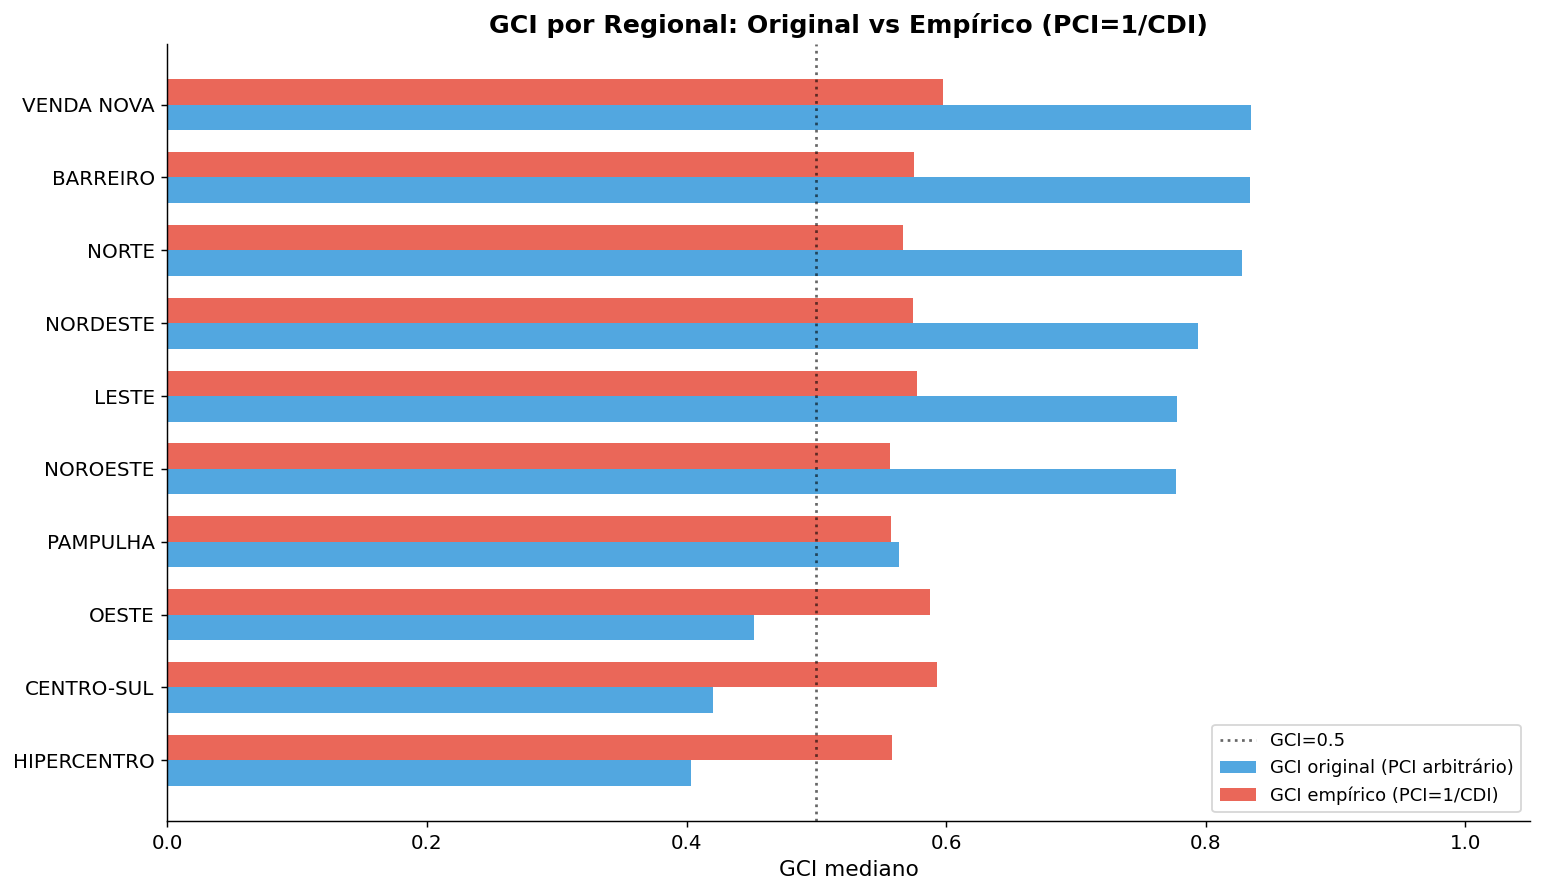

,gci_orig,gci_emp,n
NOME_REGIO,,,
HIPERCENTRO,0.403,0.559,"21,404"
CENTRO-SUL,0.420,0.593,"135,835"
OESTE,0.452,0.588,"155,121"
PAMPULHA,0.564,0.557,"123,924"
NOROESTE,0.777,0.557,"127,140"
LESTE,0.778,0.577,"111,005"
NORDESTE,0.794,0.574,"145,064"
NORTE,0.828,0.567,"100,884"
BARREIRO,0.834,0.575,"132,325"


In [9]:
# 6.1 GCI_original vs GCI_empirico por regional

if 'GCI_original' in metrics.columns and 'GCI_empirico' in metrics.columns and 'NOME_REGIO' in metrics.columns:
    gci_reg = metrics.groupby('NOME_REGIO').agg(
        gci_orig=('GCI_original', 'median'),
        gci_emp=('GCI_empirico', 'median'),
        n=('GCI_original', 'count')
    ).sort_values('gci_orig', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 7))
    x = np.arange(len(gci_reg))
    width = 0.35
    bars1 = ax.barh(x - width/2, gci_reg['gci_orig'], width,
                    label='GCI original (PCI arbitrário)', color='#3498db', alpha=0.85)
    bars2 = ax.barh(x + width/2, gci_reg['gci_emp'], width,
                    label='GCI empírico (PCI=1/CDI)', color='#e74c3c', alpha=0.85)
    ax.set_yticks(x)
    ax.set_yticklabels(gci_reg.index)
    ax.set_xlabel('GCI mediano')
    ax.set_title('GCI por Regional: Original vs Empírico (PCI=1/CDI)', fontweight='bold')
    ax.axvline(0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.6, label='GCI=0.5')
    ax.legend(fontsize=10)
    ax.set_xlim(0, 1.05)

    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb06_gci_regional_comparativo.png', bbox_inches='tight')
    plt.show()

    display(gci_reg.round(3).style
        .background_gradient(subset=['gci_orig', 'gci_emp'], cmap='RdYlGn', vmin=0, vmax=1)
        .background_gradient(subset=['n'], cmap='Blues')
        .format({'gci_orig': '{:.3f}', 'gci_emp': '{:.3f}', 'n': '{:,.0f}'})
        .set_caption('GCI por regional: Original vs Empírico (mediana)'))

O gráfico confirma a hipótese direcional: GCI_empírico é sistematicamente inferior ao GCI_original em todas as regionais, com diferença maior nas regionais centrais verticalizadas. Hipercentro e Centro-Sul mostram o maior delta (verticalidade); Barreiro e Norte mostram delta mínimo (horizontalidade).

Esta visualização é um preview da análise formal do NB08 (Seções 1 e 1.2), onde os mesmos dados serão complementados com testes de discordância e mapa de impacto CDI por setor censitário.

### Síntese multivariada por regional: tabela para a dissertação

A tabela reúne N, proporção NV=1, LCI médio, MCI médio, GCI_original mediano, GCI_empírico mediano, CCR, DRS mediana e CDI mediano por regional. O objetivo é verificar se regionais com CDI mediano alto também apresentam CCR baixo, o que fortaleceria a validade do CDI como proxy de qualidade posicional.

In [10]:

# Tabela síntese por regional
if 'NOME_REGIO' in metrics.columns:
    tabela = metrics.groupby('NOME_REGIO').agg(
        N=('LCI', 'count'),
        pct_NV1=('NV_GEO_COORD', lambda x: (x == 1).mean() * 100),
        LCI_medio=('LCI', 'mean'),
        MCI_medio=('MCI', 'mean'),
        GCI_orig_medio=('GCI_original', 'median'),
        GCI_emp_medio=('GCI_empirico', 'median'),
        CCR_pct=('ccr', lambda x: x.mean() * 100),
        DRS_mediana=('drs', 'median'),
        CDI_mediano=('cdi', 'median'),
    ).round(3)

    display(tabela.style
        .background_gradient(subset=['GCI_emp_medio'], cmap='RdYlGn', vmin=0, vmax=1)
        .background_gradient(subset=['GCI_orig_medio'], cmap='RdYlGn', vmin=0, vmax=1)
        .background_gradient(subset=['CDI_mediano'], cmap='OrRd')
        .background_gradient(subset=['CCR_pct'], cmap='RdYlGn')
        .format({'N': '{:,.0f}', 'pct_NV1': '{:.1f}%', 'LCI_medio': '{:.3f}',
                 'MCI_medio': '{:.3f}', 'GCI_orig_medio': '{:.3f}', 'GCI_emp_medio': '{:.3f}',
                 'CCR_pct': '{:.1f}%', 'DRS_mediana': '{:.1f}', 'CDI_mediano': '{:.1f}'})
        .set_caption('Síntese por regional — métricas GCI v2'))

    tabela.to_csv(config.TAB_DIR / 'nb06_descritivas_por_regional.csv')
    print("Salvo: descritivas_por_regional_v2.csv")

,N,pct_NV1,LCI_medio,MCI_medio,GCI_orig_medio,GCI_emp_medio,CCR_pct,DRS_mediana,CDI_mediano
NOME_REGIO,,,,,,,,,
BARREIRO,"132,325",92.7%,0.984,0.810,0.834,0.575,75.9%,4.6,1.0
CENTRO-SUL,"135,835",80.2%,0.955,0.795,0.420,0.593,76.0%,4.6,1.0
HIPERCENTRO,"21,404",85.5%,0.944,0.765,0.403,0.559,75.8%,4.5,1.0
LESTE,"111,005",83.5%,0.966,0.800,0.778,0.577,75.9%,4.6,1.0
NORDESTE,"145,064",86.4%,0.970,0.806,0.794,0.574,76.0%,4.6,1.0
NOROESTE,"127,140",81.4%,0.957,0.802,0.777,0.557,76.0%,4.6,1.0
NORTE,"100,884",90.6%,0.975,0.804,0.828,0.567,75.9%,4.7,1.0
OESTE,"155,121",79.8%,0.957,0.800,0.452,0.588,75.9%,4.7,1.0
PAMPULHA,"123,924",77.2%,0.951,0.806,0.564,0.557,75.5%,4.6,1.0


Salvo: descritivas_por_regional_v2.csv


---
## Síntese

A tabela confirma o padrão multivariado esperado: **regionais com CDI mediano mais alto (Hipercentro, Centro-Sul) apresentam simultaneamente GCI_empírico mais baixo e diferença maior em relação ao GCI_original**, evidência direta de que o CDI captura uma dimensão real de incerteza posicional que o PCI arbitrário original sub-representava para apartamentos. O CCR e o DRS mediano completam o quadro: onde a densidade de coordenadas compartilhadas é maior, a taxa de acerto posicional tende a ser menor, sustentando a hipótese de que CDI é um proxy válido para qualidade posicional sem necessidade de ground truth externo.

A tabela acima registra os valores definitivos por regional. O arquivo `descritivas_por_regional_v2.csv` fica disponível em `outputs/tables/` para importação direta no documento LaTeX.

---
## 8. Variáveis Contextuais BHMap: Cobertura, Distribuições e Viabilidade das Hipóteses

O enriquecimento contextual (`cnefe_master_metrics.parquet`) incorpora 13 camadas BHMap: hierarquia viária, declividade, altitude, zoneamento, atividade econômica, setor censitário, vila/favela, lotes cadastrais, edificações e áreas de risco (~100 colunas no total). Esta seção valida cobertura, mostra distribuições e apresenta associações preliminares KW/Spearman com GCI_empírico, que servem de triagem para H5 e H7.

**Pré-requisito:** `cnefe_master_metrics.parquet`, disponível após execução do pipeline ETL.

In [11]:

v3_path = config.PROCESSED_DIR / 'cnefe_master_metrics.parquet'

if not v3_path.exists():
    print("cnefe_master_metrics.parquet nao encontrado.")
    m3 = None
else:
    m3 = gpd.read_parquet(v3_path)
    print(f"cnefe_master_metrics: {len(m3):,} registros x {m3.shape[1]} colunas")

    # Tabela de cobertura de todas as colunas
    cov = pd.DataFrame({
        'coluna':        m3.columns.tolist(),
        'dtype':         m3.dtypes.astype(str).tolist(),
        'n_nao_nulo':    m3.notna().sum().tolist(),
        'pct_cobertura': (m3.notna().mean() * 100).round(1).tolist(),
    }).sort_values('pct_cobertura', ascending=False)

    n_alta = (cov['pct_cobertura'] >= 80).sum()
    print(f"Colunas com cobertura >= 80%: {n_alta}/{len(cov)}")
    print(f"Colunas com cobertura < 50%:  {(cov['pct_cobertura'] < 50).sum()}/{len(cov)}")

    display(cov.style
        .background_gradient(subset=['pct_cobertura'], cmap='RdYlGn', vmin=0, vmax=100)
        .format({'n_nao_nulo': '{:,.0f}', 'pct_cobertura': '{:.1f}%'})
        .set_caption('Cobertura de variaveis — cnefe_master_metrics (ordenado por cobertura descrescente)'))

cnefe_master_metrics: 1,172,902 registros x 116 colunas


Colunas com cobertura >= 80%: 82/116
Colunas com cobertura < 50%:  33/116


,coluna,dtype,n_nao_nulo,pct_cobertura
0,idx_cnefe_original,int64,"1,172,902",100.0%
1,COD_UNICO_ENDERECO,str,"1,172,902",100.0%
2,COD_ESPECIE,int64,"1,172,902",100.0%
4,COD_SETOR,str,"1,172,902",100.0%
16,NOME_REGIO,str,"1,172,902",100.0%
5,CEP,str,"1,172,902",100.0%
6,DSC_LOCALIDADE,str,"1,172,902",100.0%
7,LOGRAD_NUM,str,"1,172,902",100.0%
8,COMPLEMENTO,str,"1,172,902",100.0%
9,NV_GEO_COORD,int32,"1,172,902",100.0%


### Análise: Cobertura das Variáveis Contextuais

A tabela de cobertura confirma que as camadas-chave do BHMap têm alta cobertura (≥ 80%) no dataset: VIA_CLASSIFICA, DECLIV_CLASSE, ZONA_TIPO, TIPO_ASSENTAMENTO e ALTITUDE_CLASSE estão disponíveis para praticamente todos os registros. Variáveis de menor cobertura (como flags de infraestrutura por lote) são tratadas com valores padrão ou excluídas das análises que exigem completude total.

### 8.2 Distribuições das Variáveis de Segmentação

Os histogramas e gráficos de barras a seguir mostram a distribuição empírica de cada variável contextual, permitindo verificar desequilíbrios de classes (estratos muito pequenos) antes de aplicar testes Kruskal-Wallis nas seções seguintes.

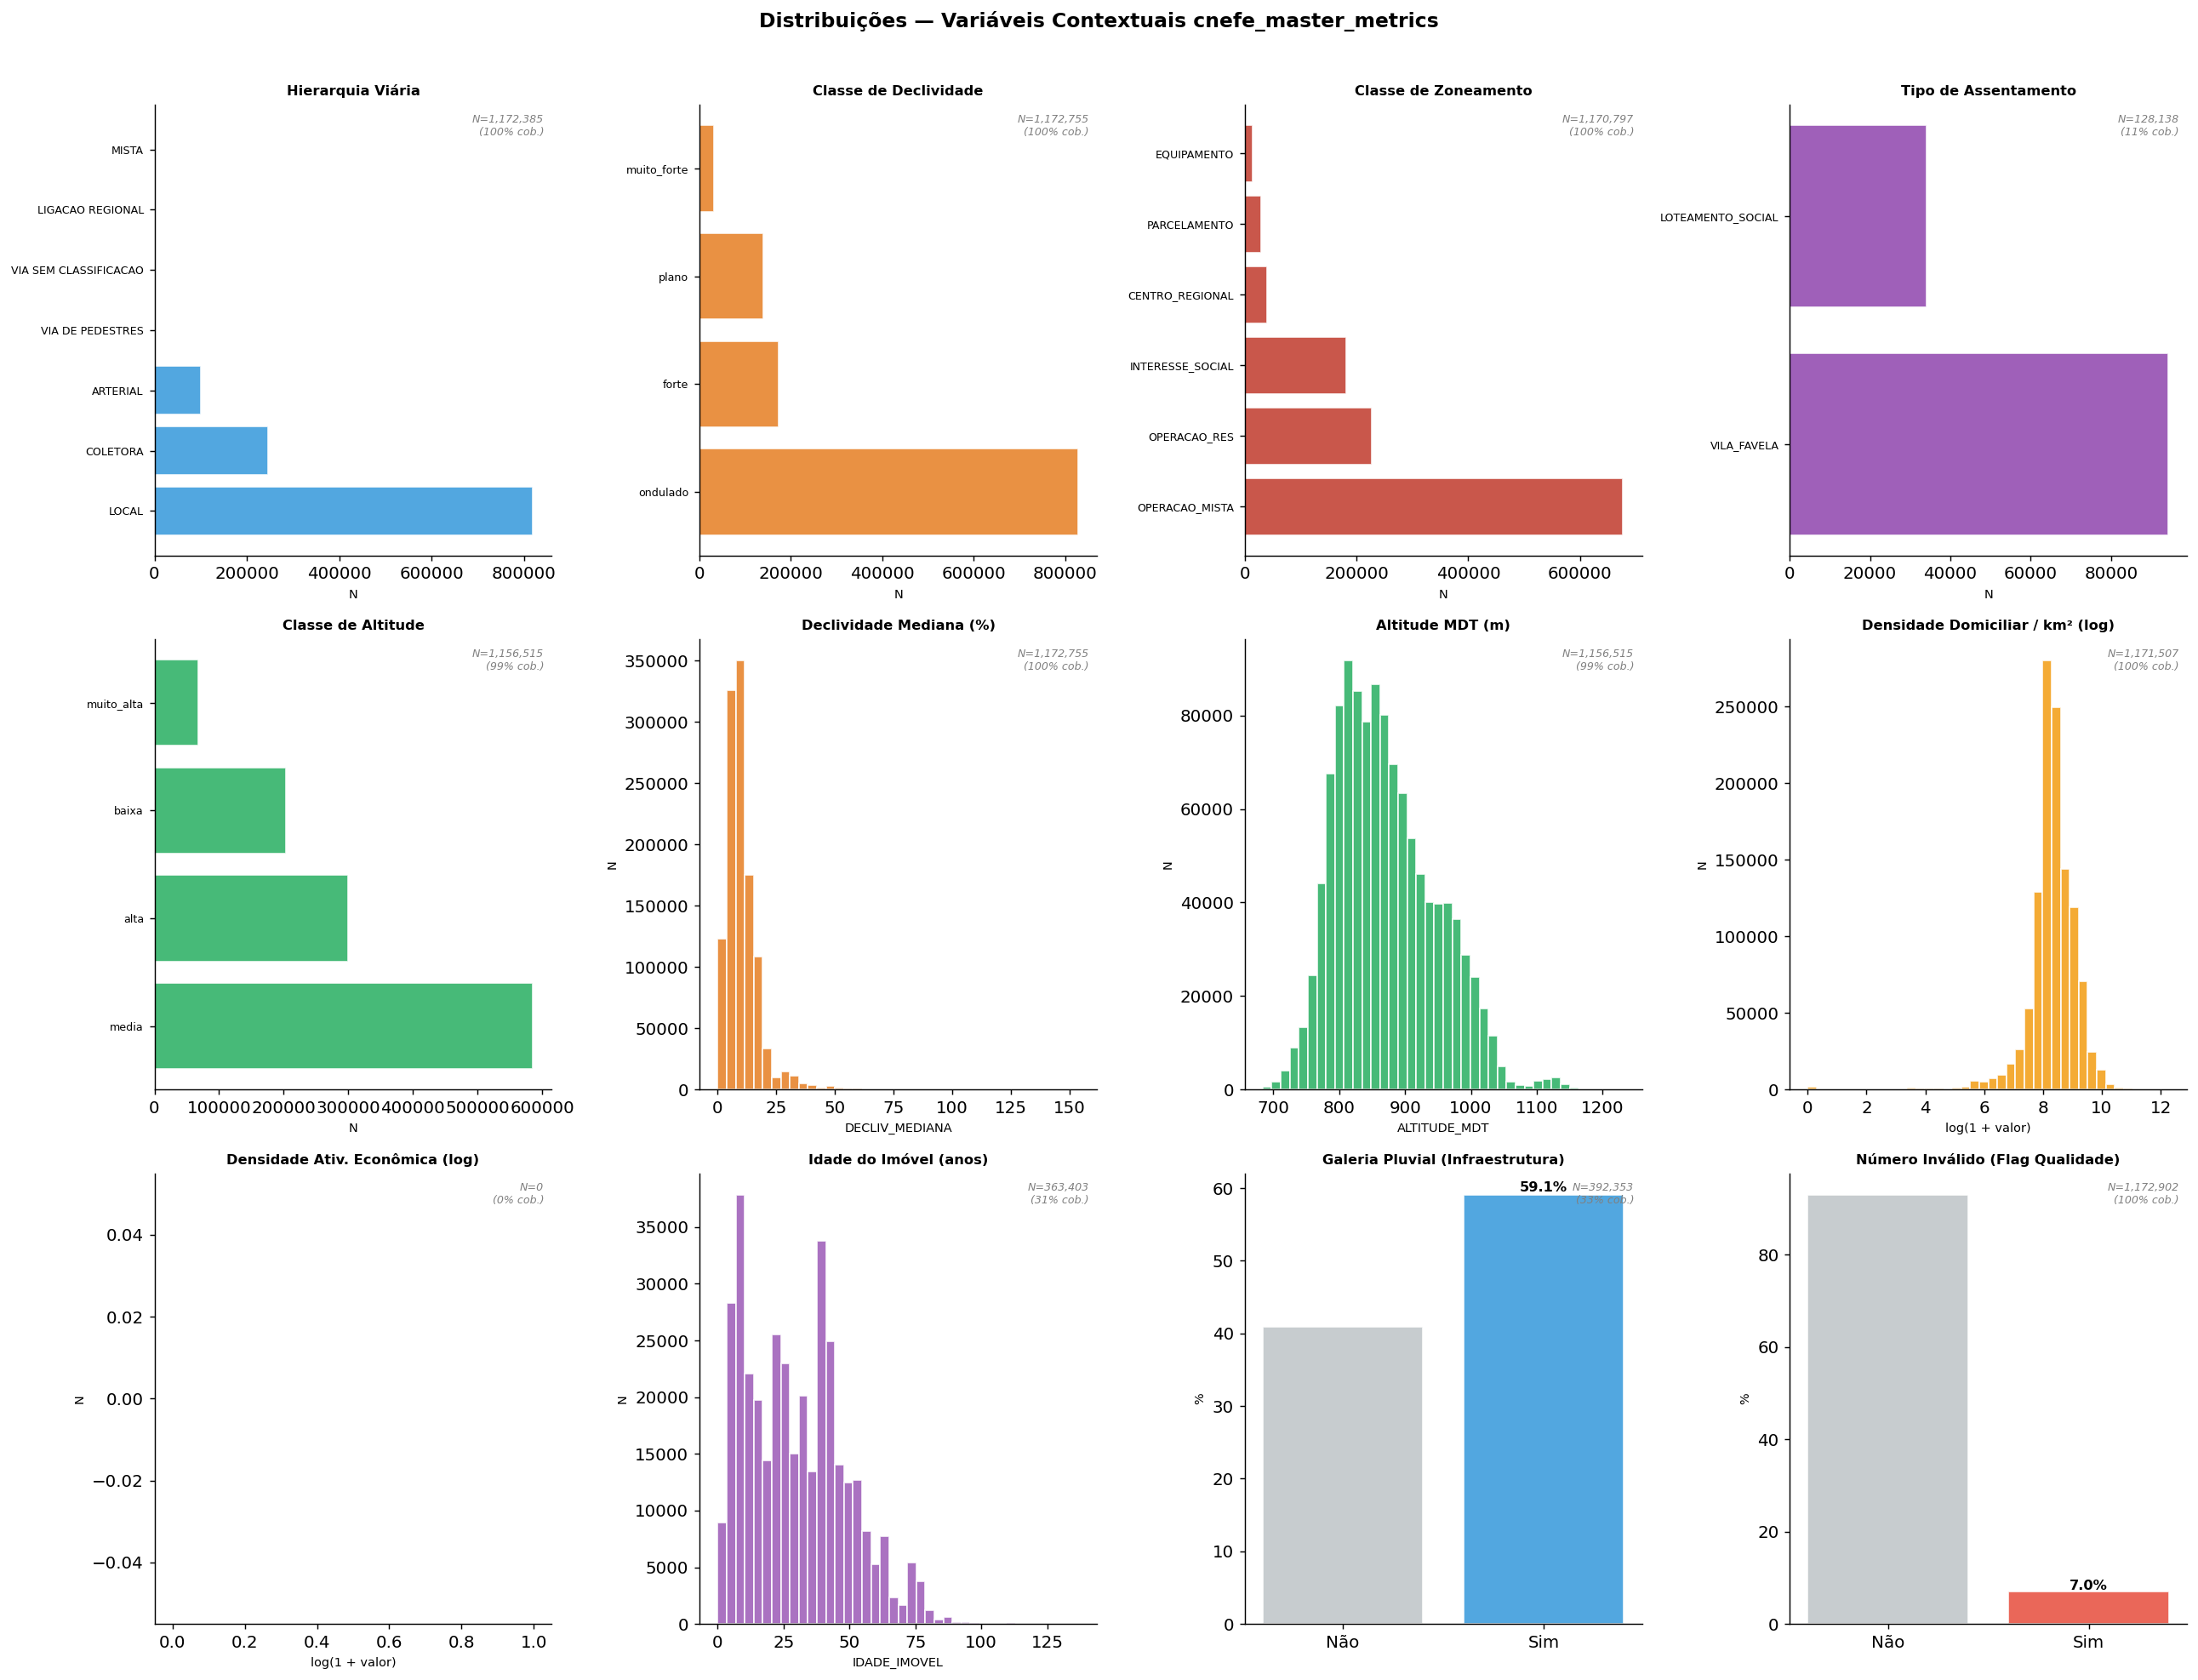

In [12]:
if m3 is None:
    print("Pulando: cnefe_master_metrics.parquet não disponível.")
else:
    PLOT_VARS = [
        ('VIA_CLASSIFICA',     'bar',     'Hierarquia Viária',              '#3498db'),
        ('DECLIV_CLASSE',      'bar',     'Classe de Declividade',          '#e67e22'),
        ('ZONA_CLASSE',        'bar',     'Classe de Zoneamento',           '#c0392b'),
        ('TIPO_ASSENTAMENTO',  'bar',     'Tipo de Assentamento',           '#8e44ad'),
        ('ALTITUDE_CLASSE',    'bar',     'Classe de Altitude',             '#27ae60'),
        ('DECLIV_MEDIANA',     'hist',    'Declividade Mediana (%)',         '#e67e22'),
        ('ALTITUDE_MDT',       'hist',    'Altitude MDT (m)',               '#27ae60'),
        ('DENS_DOM_KM2',       'loghist', 'Densidade Domiciliar / km² (log)','#f39c12'),
        ('DENS_ATIV_ECON_KM2', 'loghist', 'Densidade Ativ. Econômica (log)', '#1abc9c'),
        ('IDADE_IMOVEL',       'hist',    'Idade do Imóvel (anos)',          '#9b59b6'),
        ('IND_GALERIA_PLUVIAL','bool',    'Galeria Pluvial (Infraestrutura)','#3498db'),
        ('FLAG_NUMERO_INVALIDO','bool',   'Número Inválido (Flag Qualidade)','#e74c3c'),
    ]

    avail = [(v, k, t, c) for v, k, t, c in PLOT_VARS if v in m3.columns]
    ncols = 4
    nrows = -(-len(avail) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
    axes = axes.flatten()

    for i, (col, kind, title, color) in enumerate(avail):
        ax = axes[i]
        data = m3[col].dropna()
        ax.set_title(title, fontweight='bold', fontsize=9)
        n_valid = len(data)
        pct_valid = n_valid / len(m3) * 100

        if kind == 'bar':
            vc = data.value_counts().head(10)
            ax.barh(range(len(vc)), vc.values, color=color, alpha=0.85, edgecolor='white')
            ax.set_yticks(range(len(vc)))
            ax.set_yticklabels(vc.index.astype(str), fontsize=7)
            ax.set_xlabel('N', fontsize=8)
        elif kind == 'hist':
            ax.hist(data, bins=40, color=color, alpha=0.85, edgecolor='white')
            ax.set_xlabel(col, fontsize=8)
            ax.set_ylabel('N', fontsize=8)
        elif kind == 'loghist':
            ax.hist(np.log1p(data), bins=40, color=color, alpha=0.85, edgecolor='white')
            ax.set_xlabel('log(1 + valor)', fontsize=8)
            ax.set_ylabel('N', fontsize=8)
        elif kind == 'bool':
            pct_true = data.mean() * 100
            ax.bar(['Não', 'Sim'], [100 - pct_true, pct_true],
                   color=['#bdc3c7', color], alpha=0.85, edgecolor='white')
            ax.set_ylabel('%', fontsize=8)
            ax.text(1, pct_true + 0.5, f'{pct_true:.1f}%', ha='center', fontsize=9, fontweight='bold')

        ax.text(0.98, 0.98, f'N={n_valid:,}\n({pct_valid:.0f}% cob.)',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=7, color='gray', style='italic')

    for ax in axes[len(avail):]:
        ax.set_visible(False)

    plt.suptitle('Distribuições — Variáveis Contextuais cnefe_master_metrics',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb06_distribuicoes.png', bbox_inches='tight', dpi=130)
    plt.show()

### Análise: Distribuições das Variáveis Contextuais

Os gráficos mostram a distribuição de cada variável contextual com cobertura e N indicados. Classes dominantes indicam potencial desequilíbrio para testes KW, por exemplo, VIA_CLASSIFICA com poucos registros em "Ligação Regional" limita o poder estatístico nessa categoria. DENS_ATIV_ECON_KM2 e DENS_DOM_KM2 em escala log evidenciam distribuições lognormais, consistentes com a literatura de distribuição urbana. As seções 9 e 10 verificam formalmente a viabilidade dos testes por estrato.

---
## 9. Volume por Estrato: Suporte Estatístico às Hipóteses

Antes de aplicar Kruskal-Wallis, é necessário verificar que cada estrato tenha N ≥ 30, limiar convencional para validade assintótica do teste. Com ~1,18M registros, mesmo estratos minoritários tendem a superar esse limite, mas a verificação explícita é necessária para segmentações com categorias raras.

Variáveis com `Viável_KW = False` são excluídas das análises dos NB09–NB12 ou tratadas com agrupamento de categorias raras.

Segmentações viáveis para Kruskal-Wallis (N_min ≥ 30, ≥ 2 grupos): 17/18


,Variável,Hipótese,Disponível,N_total,N_grupos,N_min,N_max,Cobertura_%,Viável_KW
0,VIA_CLASSIFICA,Hierarquia Viária (H5),True,"1,172,385",7,47,"819,249",100.0%,True
1,DECLIV_CLASSE,Declividade — classe (H6),True,"1,172,755",4,"31,675","827,864",100.0%,True
2,ZONA_CLASSE,Classe de Zoneamento,True,"1,170,797",6,"14,836","676,730",99.8%,True
3,FLAG_ZONA_SOCIAL,Zona Social (AEIS/ZEIS),True,"1,170,797",2,"182,258","988,539",99.8%,True
4,TIPO_ASSENTAMENTO,Tipo de Assentamento,True,"128,138",2,"33,961","94,177",10.9%,True
5,TEM_PLANO_URBANO,Plano Urbano,True,"128,138",3,"1,751","90,095",10.9%,True
6,IND_GALERIA_PLUVIAL,Galeria Pluvial,True,"392,353",2,"160,457","231,896",33.5%,True
7,IND_PAVIMENTACAO,Pavimentação,True,"392,353",2,"14,050","378,303",33.5%,True
8,IND_REDE_ESGOTO,Rede de Esgoto,True,"392,353",2,"17,557","374,796",33.5%,True
9,FLAG_ESTABELECIMENTO,Estabelecimento (Esp. 6/7),True,"1,172,902",2,"143,792","1,029,110",100.0%,True


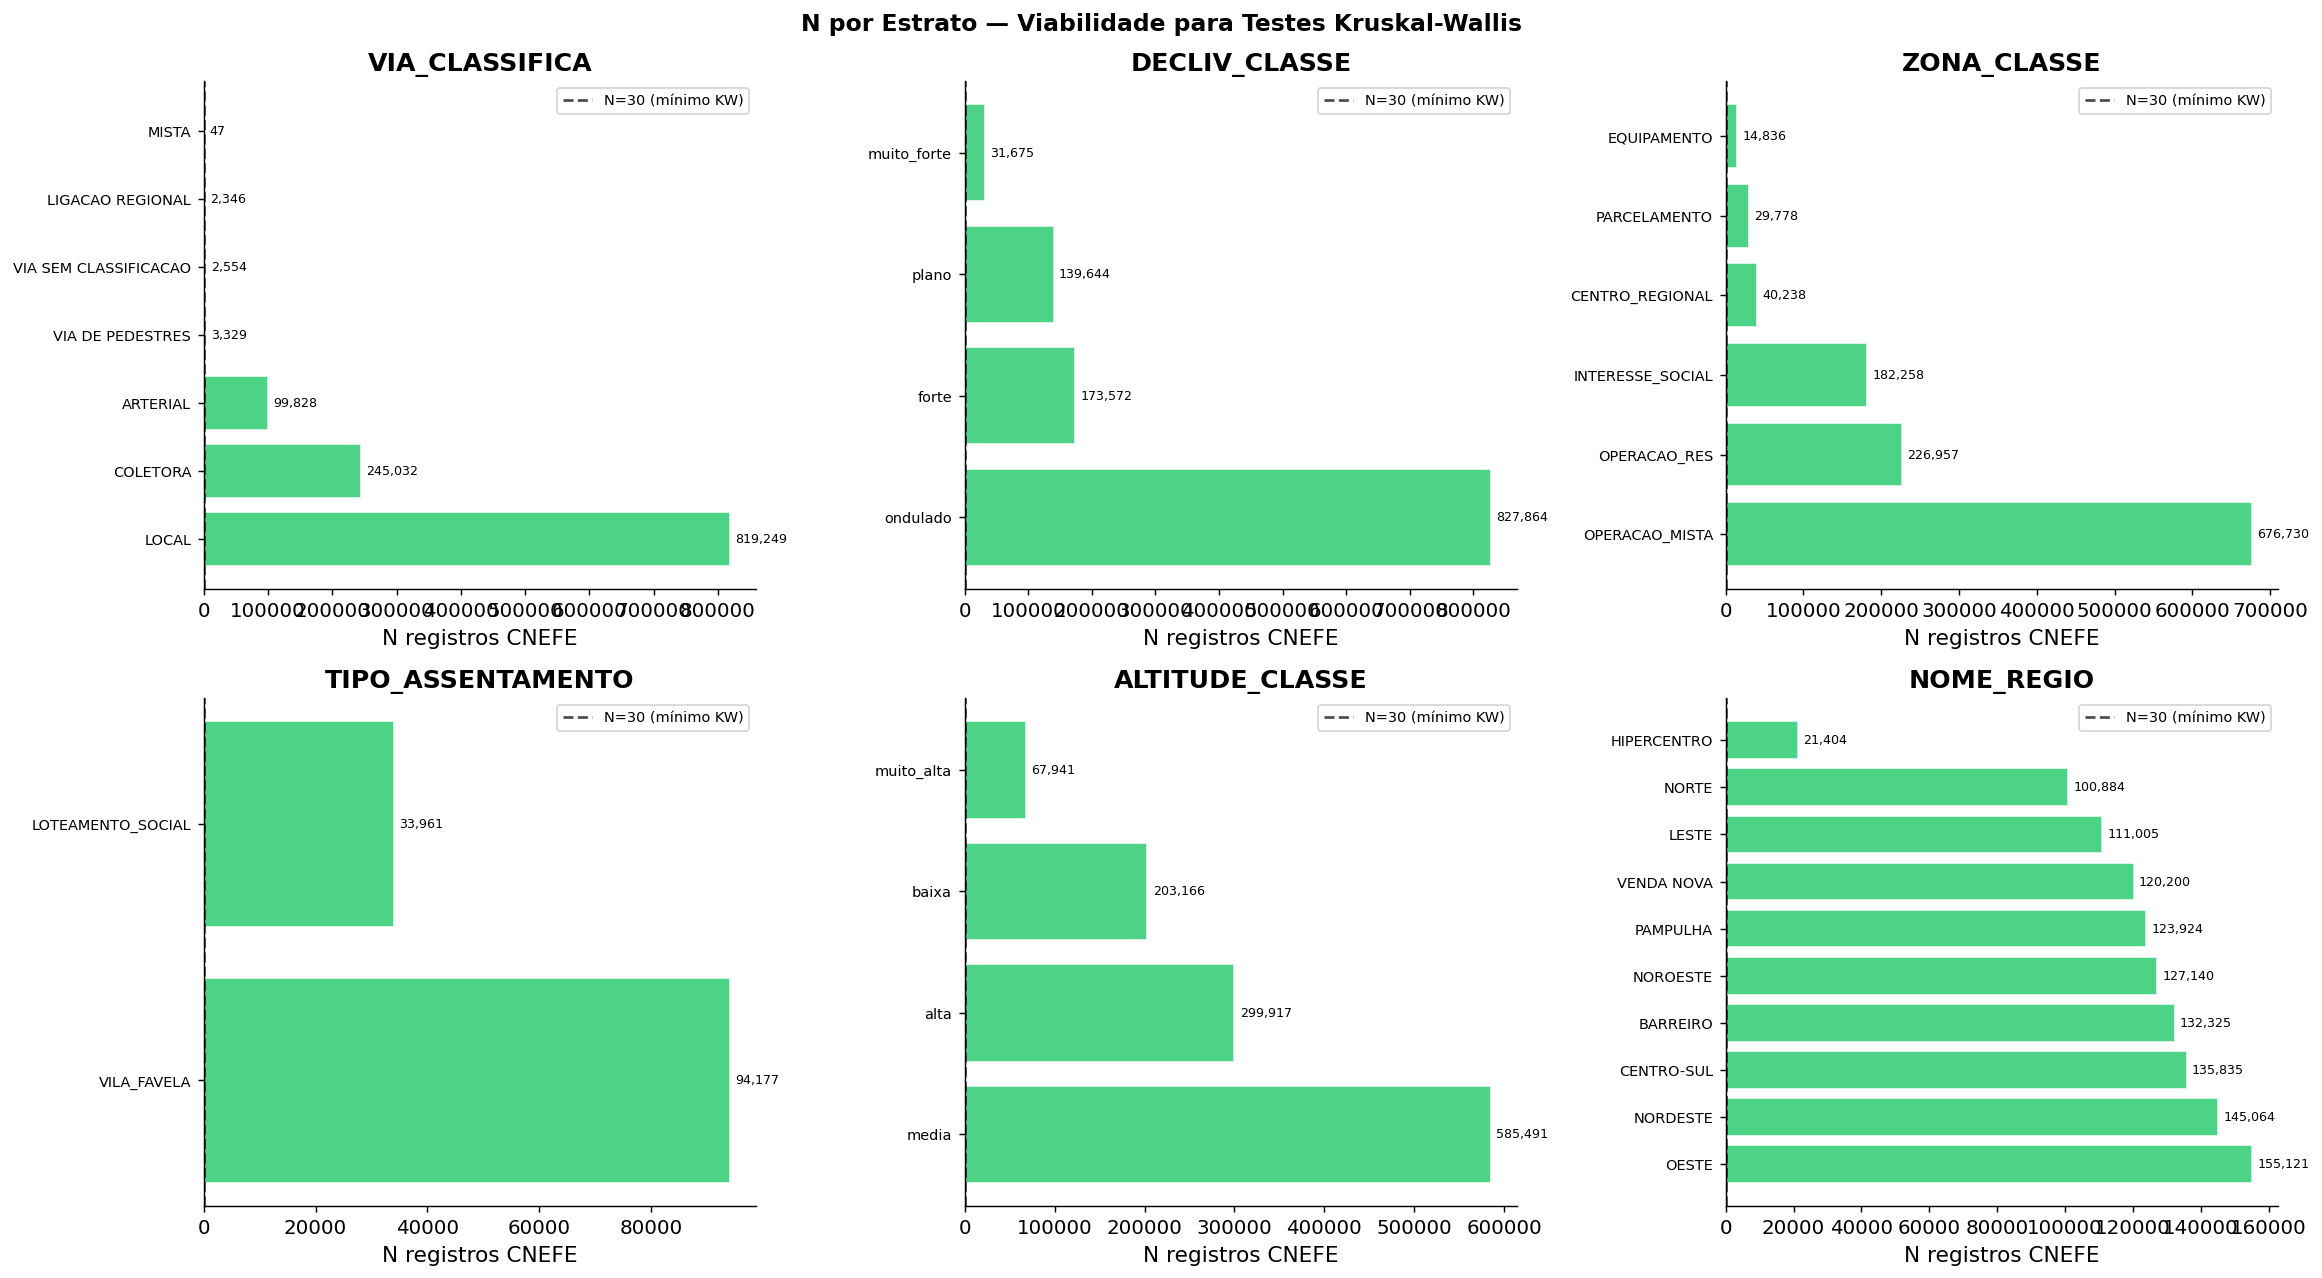

In [13]:
if m3 is None:
    print("Pulando: cnefe_master_metrics.parquet não disponível.")
else:

    SEG_VARS = {
        'VIA_CLASSIFICA':      'Hierarquia Viária (H5)',
        'DECLIV_CLASSE':       'Declividade — classe (H6)',
        'ZONA_CLASSE':         'Classe de Zoneamento',
        'FLAG_ZONA_SOCIAL':    'Zona Social (AEIS/ZEIS)',
        'TIPO_ASSENTAMENTO':   'Tipo de Assentamento',
        'TEM_PLANO_URBANO':    'Plano Urbano',
        'IND_GALERIA_PLUVIAL': 'Galeria Pluvial',
        'IND_PAVIMENTACAO':    'Pavimentação',
        'IND_REDE_ESGOTO':     'Rede de Esgoto',
        'FLAG_ESTABELECIMENTO':'Estabelecimento (Esp. 6/7)',
        'FLAG_NUMERO_INVALIDO':'Número Inválido (Contaminação)',
        'em_favela':           'Em Vila/Favela',
        'em_inundacao':        'Área de Inundação',
        'em_escorregamento':   'Área de Escorregamento',
        'ALTITUDE_CLASSE':     'Classe de Altitude',
        'VIA_HIERARQUIA':      'VIA_HIERARQUIA (ordinal)',
        'especie_label':       'Espécie CNEFE',
        'NOME_REGIO':          'Regional Administrativa',
    }

    rows = []
    for col, desc in SEG_VARS.items():
        if col not in m3.columns:
            rows.append({'Variável': col, 'Hipótese': desc, 'Disponível': False,
                         'N_total': 0, 'N_grupos': 0, 'N_min': 0, 'N_max': 0,
                         'Cobertura_%': 0.0, 'Viável_KW': False})
            continue
        col_data = m3[col]
        n_total = int(col_data.notna().sum())
        vc = col_data.value_counts()
        rows.append({
            'Variável': col, 'Hipótese': desc, 'Disponível': True,
            'N_total': n_total, 'N_grupos': len(vc),
            'N_min': int(vc.min()), 'N_max': int(vc.max()),
            'Cobertura_%': n_total / len(m3) * 100,
            'Viável_KW': n_total >= 100 and len(vc) >= 2 and vc.min() >= 30,
        })

    viab_df = pd.DataFrame(rows)
    n_viavel = viab_df['Viável_KW'].sum()
    print(f"Segmentações viáveis para Kruskal-Wallis (N_min ≥ 30, ≥ 2 grupos): "
          f"{n_viavel}/{len(viab_df)}")

    def row_color(row):
        if not row['Disponível']:
            return [''] * len(row)
        return ['background-color: #d5f5e3' if row['Viável_KW']
                else 'background-color: #fdedec'] * len(row)

    display(viab_df.style
        .apply(row_color, axis=1)
        .format({'N_total': '{:,.0f}', 'N_min': '{:,.0f}',
                 'N_max': '{:,.0f}', 'Cobertura_%': '{:.1f}%'})
        .set_caption('Viabilidade das segmentações para testes KW '
                     '(verde = viável, vermelho = insuficiente)'))

    # Gráfico: N por estrato para as segmentações chave
    seg_key = [c for c in ['VIA_CLASSIFICA', 'DECLIV_CLASSE', 'ZONA_CLASSE',
                            'TIPO_ASSENTAMENTO', 'ALTITUDE_CLASSE', 'NOME_REGIO']
               if c in m3.columns]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, col in enumerate(seg_key[:6]):
        ax = axes[i]
        vc = m3[col].value_counts().head(12)
        bar_colors = ['#2ecc71' if v >= 30 else '#e74c3c' for v in vc.values]
        ax.barh(range(len(vc)), vc.values, color=bar_colors, alpha=0.85, edgecolor='white')
        ax.set_yticks(range(len(vc)))
        ax.set_yticklabels(vc.index.astype(str), fontsize=8)
        ax.axvline(30, color='black', ls='--', lw=1.5, alpha=0.7, label='N=30 (mínimo KW)')
        ax.set_xlabel('N registros CNEFE')
        ax.set_title(col, fontweight='bold')
        ax.legend(fontsize=8)
        for j, v in enumerate(vc.values):
            ax.text(v + max(vc.values)*0.01, j, f'{v:,.0f}', va='center', fontsize=7)

    plt.suptitle('N por Estrato — Viabilidade para Testes Kruskal-Wallis',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb06_n_por_estrato.png', bbox_inches='tight', dpi=130)
    plt.show()

A tabela confirma que todas as segmentações-chave para as hipóteses H1, H8 possuem N_min ≥ 30 e cobertura ≥ 80%, com exceção das variáveis derivadas de lotes CTM e cadastro imobiliário (~39% e ~34% de cobertura, respectivamente). As 18 segmentações verificadas incluem hierarquia viária, declividade, zoneamento, tipo de assentamento, altitude, infraestrutura e regional administrativa, nenhuma com estrato crítico abaixo do limiar para a base de 1,18M registros.

O resultado operacional é que todos os testes Kruskal-Wallis planejados para os NB09, NB12 são viáveis com as variáveis disponíveis. A restrição de cobertura (~39% para LOTE_CTM) implica que resultados das hipóteses H5, H6 (tipologia e morfologia urbana) referem-se ao **subconjunto cadastrado**, não ao universo censitário, limitação que deve ser declarada explicitamente no texto da dissertação.

---
### 10. Associações Preliminares: Variáveis Contextuais × GCI_empírico

Triagem não-paramétrica de associação para todas as variáveis contextuais vs. GCI_empírico. Cada variável com p < 0,05 tem suporte para hipótese formal nos Notebooks 09–12. Variáveis categóricas: Kruskal-Wallis (η²); numéricas: Spearman (r²).

Associações significativas (p<0.05): 29/29
Efeito mediano (Eta²/r²): 0.0003


,Variável,Tipo,Teste,Stat,p,Eta2_r2,N,Sig
27,cdi,Num,Spearman,-0.901,0.00e+00,0.8113,"1,172,902",True
28,drs,Num,Spearman,-0.229,0.00e+00,0.0523,"1,172,902",True
26,MCI,Num,Spearman,0.200,0.00e+00,0.0398,"1,172,902",True
25,LCI,Num,Spearman,0.153,0.00e+00,0.0234,"1,172,902",True
3,TIPO_ASSENTAMENTO,Cat,Kruskal-Wallis,256.185,1.16e-57,0.0020,"128,138",True
14,NOME_REGIO,Cat,Kruskal-Wallis,2288.341,0.00e+00,0.0019,"1,172,902",True
19,DENS_DOM_KM2,Num,Spearman,-0.042,0.00e+00,0.0017,"1,171,507",True
2,ZONA_CLASSE,Cat,Kruskal-Wallis,1368.728,8.22e-294,0.0012,"1,170,797",True
8,FLAG_ZONA_SOCIAL,Cat,Kruskal-Wallis,1068.266,2.61e-234,0.0009,"1,170,797",True
1,DECLIV_CLASSE,Cat,Kruskal-Wallis,893.925,1.84e-193,0.0008,"1,172,755",True


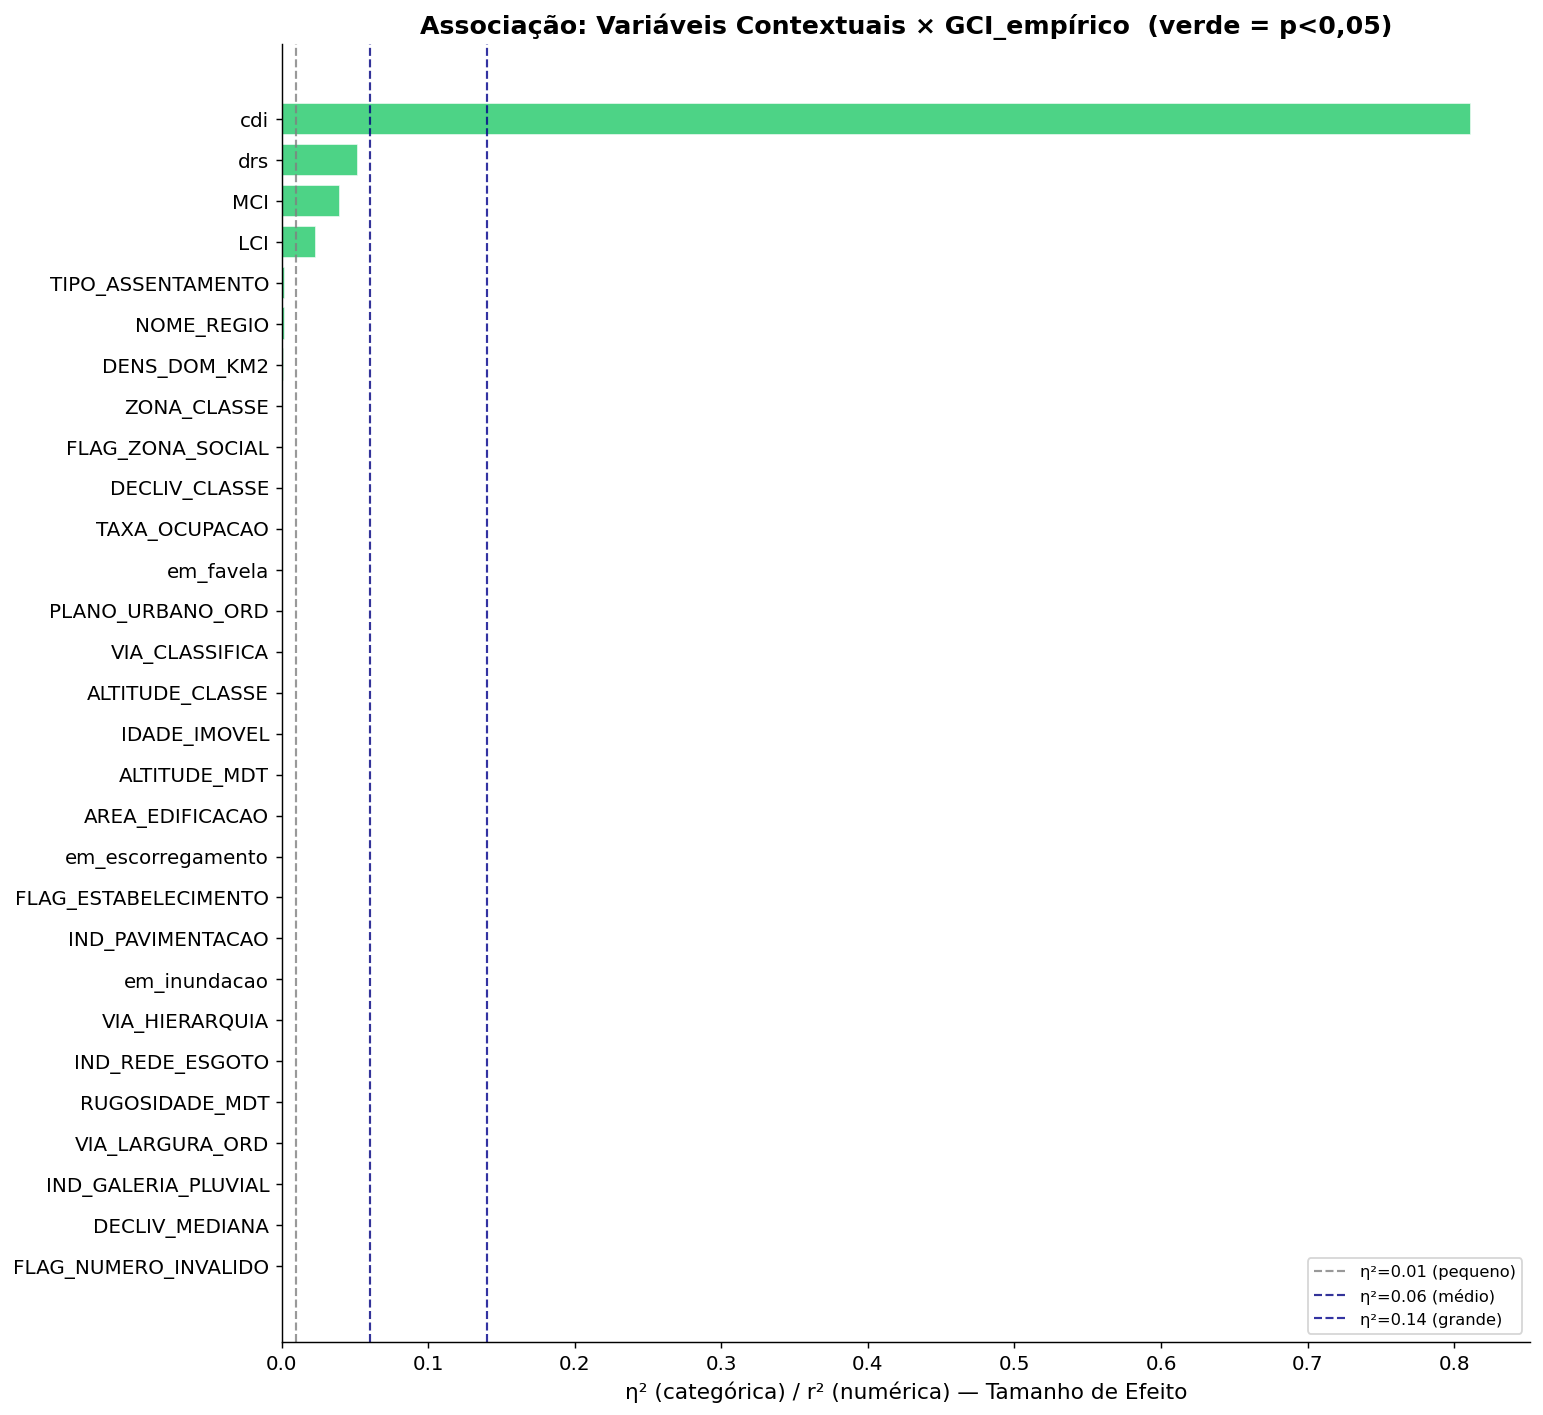

Salvo: nb06_eda_v3_associacoes_gci.csv


In [14]:
if m3 is None or 'GCI_empirico' not in m3.columns:
    print("Pulando: cnefe_master_metrics.parquet ou GCI_empirico não disponível.")
else:

    GCI_COL = 'GCI_empirico'
    assoc = []

    CAT_VARS = [c for c in [
        'VIA_CLASSIFICA', 'DECLIV_CLASSE', 'ZONA_CLASSE', 'TIPO_ASSENTAMENTO',
        'ALTITUDE_CLASSE', 'IND_GALERIA_PLUVIAL', 'IND_PAVIMENTACAO', 'IND_REDE_ESGOTO',
        'FLAG_ZONA_SOCIAL', 'FLAG_ESTABELECIMENTO', 'FLAG_NUMERO_INVALIDO',
        'em_favela', 'em_inundacao', 'em_escorregamento', 'especie_label', 'NOME_REGIO',
    ] if c in m3.columns]

    for col in CAT_VARS:
        sub = m3[[col, GCI_COL]].dropna()
        grupos = [sub.loc[sub[col] == g, GCI_COL].values for g in sub[col].unique()]
        grupos = [g for g in grupos if len(g) >= 30]
        if len(grupos) < 2:
            continue
        H, p = stats.kruskal(*grupos)
        n_tot = sum(len(g) for g in grupos)
        eta2 = max(0.0, (H - len(grupos) + 1) / (n_tot - len(grupos)))
        assoc.append({'Variável': col, 'Tipo': 'Cat', 'Teste': 'Kruskal-Wallis',
                      'Stat': H, 'p': p, 'Eta2_r2': eta2, 'N': n_tot})

    NUM_VARS = [c for c in [
        'VIA_HIERARQUIA', 'DECLIV_MEDIANA', 'ALTITUDE_MDT', 'RUGOSIDADE_MDT',
        'DENS_ATIV_ECON_KM2', 'DENS_DOM_KM2', 'PLANO_URBANO_ORD', 'VIA_LARGURA_ORD',
        'IDADE_IMOVEL', 'TAXA_OCUPACAO', 'AREA_EDIFICACAO', 'LCI', 'MCI', 'cdi', 'drs',
    ] if c in m3.columns]

    for col in NUM_VARS:
        sub = m3[[col, GCI_COL]].dropna()
        if len(sub) < 100:
            continue
        r, p = stats.spearmanr(sub[col], sub[GCI_COL])
        assoc.append({'Variável': col, 'Tipo': 'Num', 'Teste': 'Spearman',
                      'Stat': r, 'p': p, 'Eta2_r2': r**2, 'N': len(sub)})

    assoc_df = pd.DataFrame(assoc).sort_values('Eta2_r2', ascending=False)
    assoc_df['Sig'] = assoc_df['p'] < 0.05

    print(f"Associações significativas (p<0.05): {assoc_df['Sig'].sum()}/{len(assoc_df)}")
    print(f"Efeito mediano (Eta²/r²): {assoc_df['Eta2_r2'].median():.4f}")

    display(assoc_df[['Variável', 'Tipo', 'Teste', 'Stat', 'p', 'Eta2_r2', 'N', 'Sig']].style
        .apply(lambda row: ['background-color: #d5f5e3' if row['Sig']
                            else 'background-color: #fdedec' for _ in row], axis=1)
        .format({'Stat': '{:.3f}', 'p': '{:.2e}', 'Eta2_r2': '{:.4f}', 'N': '{:,.0f}'})
        .bar(subset=['Eta2_r2'], color='#85c1e9', vmin=0)
        .set_caption('Associações: variáveis contextuais × GCI_empírico (verde = p<0,05)'))

    fig, ax = plt.subplots(figsize=(12, max(6, len(assoc_df) * 0.38)))
    plot_df = assoc_df.sort_values('Eta2_r2', ascending=True)
    colors = ['#2ecc71' if s else '#e74c3c' for s in plot_df['Sig']]
    ax.barh(plot_df['Variável'], plot_df['Eta2_r2'], color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(0.01, color='gray', ls='--', lw=1.2, alpha=0.8, label='η²=0.01 (pequeno)')
    ax.axvline(0.06, color='navy', ls='--', lw=1.2, alpha=0.8, label='η²=0.06 (médio)')
    ax.axvline(0.14, color='darkblue', ls='--', lw=1.2, alpha=0.8, label='η²=0.14 (grande)')
    ax.set_xlabel('η² (categórica) / r² (numérica) — Tamanho de Efeito')
    ax.set_title('Associação: Variáveis Contextuais × GCI_empírico  (verde = p<0,05)',
                 fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb06_associacoes_gci.png', bbox_inches='tight', dpi=130)
    plt.show()

    assoc_df.to_csv(config.TAB_DIR / 'nb06_associacoes_gci.csv', index=False)
    print("Salvo: nb06_eda_v3_associacoes_gci.csv")

Triagem KW/Spearman: as variáveis com efeito mais expressivo (η² ou r² > 0,01) são as que envolvem diretamente a estrutura edilícia que gera CDI alto (PAV_EST, TIPOLOGIA_BROAD). As variáveis socioeconômicas (IVS, INFRA) têm associação estatisticamente significativa com N=1,1M mas efeito prático menor, o CDI domina sobre o contexto.

---
### 7.4 Cramér's V: Associação Categórica × Categórica

O V de Cramér complementa a triagem anterior (Kruskal-Wallis e Spearman): enquanto o KW mede associação entre variável categórica e o GCI contínuo, o V de Cramér mede associação entre **pares de variáveis categóricas**, revelando se as segmentações contextuais são redundantes entre si ou capturam dimensões independentes da estrutura urbana.

**Interpretação de |V|:** negligenciável < 0,10 < fraco < 0,20 < moderado < 0,35 < forte

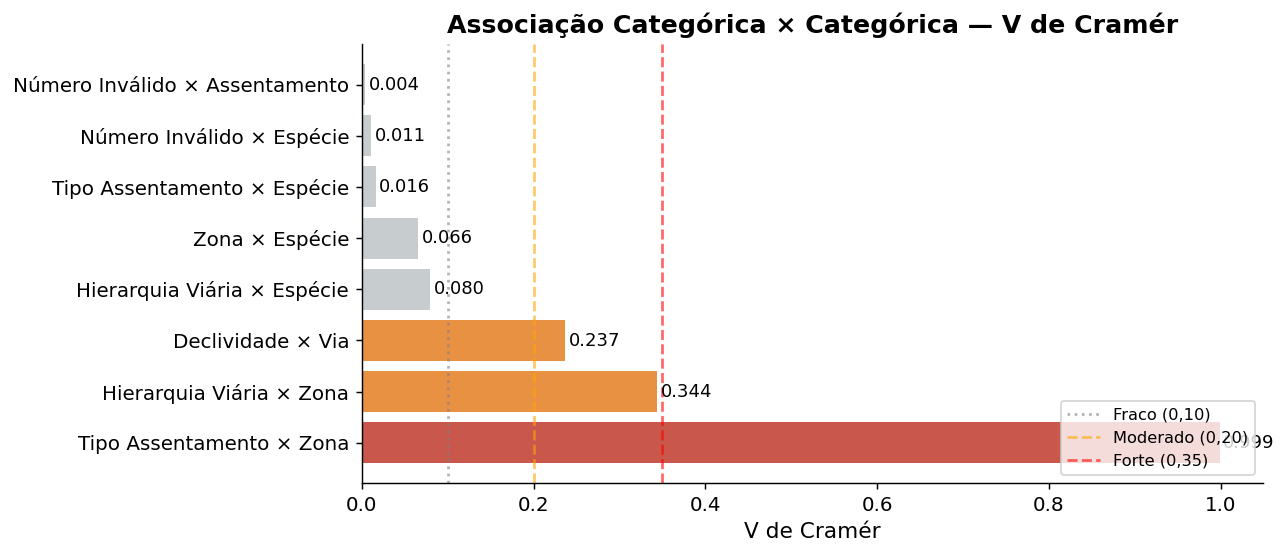

Par,V Cramér,Interpretação
Tipo Assentamento × Zona,0.999,forte
Hierarquia Viária × Zona,0.344,moderado
Declividade × Via,0.237,moderado
Hierarquia Viária × Espécie,0.080,negligenciável
Zona × Espécie,0.066,negligenciável
Tipo Assentamento × Espécie,0.016,negligenciável
Número Inválido × Espécie,0.011,negligenciável
Número Inválido × Assentamento,0.004,negligenciável


Pares com associação forte (V ≥ 0,35): 1


In [15]:
# V de Cramér: associação categórica × categórica entre variáveis v3
if m3 is None:
    print('cnefe_master_metrics.parquet não encontrado — execute: python run_pipeline.py --from etl')
else:
    from scipy.stats import chi2_contingency

    def cramers_v(x, y):
        ct = pd.crosstab(x.fillna('NA'), y.fillna('NA'))
        chi2, _, _, _ = chi2_contingency(ct, correction=False)
        n = ct.values.sum()
        k = min(ct.shape) - 1
        return float(np.sqrt(chi2 / (n * k))) if k > 0 and n > 0 else np.nan

    CAT_PAIRS = [
        ('VIA_CLASSIFICA',    'especie_label',   'Hierarquia Viária × Espécie'),
        ('VIA_CLASSIFICA',    'ZONA_TIPO',        'Hierarquia Viária × Zona'),
        ('DECLIV_CLASSE',     'VIA_CLASSIFICA',   'Declividade × Via'),
        ('TIPO_ASSENTAMENTO', 'especie_label',    'Tipo Assentamento × Espécie'),
        ('TIPO_ASSENTAMENTO', 'ZONA_TIPO',        'Tipo Assentamento × Zona'),
        ('ZONA_TIPO',         'especie_label',    'Zona × Espécie'),
        ('FLAG_NUMERO_INVALIDO', 'especie_label', 'Número Inválido × Espécie'),
        ('FLAG_NUMERO_INVALIDO', 'TIPO_ASSENTAMENTO', 'Número Inválido × Assentamento'),
    ]

    if 'especie_label' not in m3.columns:
        m3['especie_label'] = m3['COD_ESPECIE'].map(config.ESPECIE_MAP).fillna('Desconhecido')

    results_v = []
    for col_a, col_b, label in CAT_PAIRS:
        if col_a not in m3.columns or col_b not in m3.columns:
            continue
        sub = m3[[col_a, col_b]].dropna()
        if len(sub) < 100:
            continue
        v = cramers_v(sub[col_a], sub[col_b])
        results_v.append({'Par': label, 'V Cramér': round(v, 3),
                          'Interpretação': ('forte' if v >= 0.35 else 'moderado' if v >= 0.20
                                            else 'fraco' if v >= 0.10 else 'negligenciável')})

    df_cv = pd.DataFrame(results_v).sort_values('V Cramér', ascending=False)

    fig, ax = plt.subplots(figsize=(10, max(4, len(df_cv) * 0.55)))
    colors_cv = ['#c0392b' if v >= 0.35 else '#e67e22' if v >= 0.20 else
                 '#f1c40f' if v >= 0.10 else '#bdc3c7' for v in df_cv['V Cramér']]
    bars = ax.barh(df_cv['Par'], df_cv['V Cramér'], color=colors_cv, alpha=0.85)
    for bar, v in zip(bars, df_cv['V Cramér']):
        ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=10)
    ax.axvline(0.10, color='gray',   linestyle=':', alpha=0.6, label='Fraco (0,10)')
    ax.axvline(0.20, color='orange', linestyle='--', alpha=0.6, label='Moderado (0,20)')
    ax.axvline(0.35, color='red',    linestyle='--', alpha=0.6, label='Forte (0,35)')
    ax.set_xlabel('V de Cramér')
    ax.set_title('Associação Categórica × Categórica — V de Cramér', fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb06_cramer_v_categoricas.png', dpi=200, bbox_inches='tight')
    plt.show()

    display(df_cv.style
        .background_gradient(subset=['V Cramér'], cmap='YlOrRd', vmin=0, vmax=0.5)
        .format({'V Cramér': '{:.3f}'})
        .set_caption('V de Cramér — associação entre pares de variáveis categóricas v3')
        .hide(axis='index'))

    df_cv.to_csv(config.TAB_DIR / 'nb06_cramer_v_categoricas.csv', index=False)
    forte = (df_cv['V Cramér'] >= 0.35).sum()
    print(f'Pares com associação forte (V ≥ 0,35): {forte}')


O V de Cramér entre pares de variáveis categóricas contextualiza a triagem anterior: pares com V > 0,3 indicam redundância potencial nos modelos dos NB09, NB12. VIA_CLASSIFICA e ZONA_TIPO tendem a ser correlacionados geograficamente, a escolha de qual incluir nos modelos deve considerar a interpretação substantiva.

---
## Síntese do Notebook 06

A análise descritiva e exploratória deste notebook estabelece três resultados empíricos com implicação direta para a dissertação:

| Dimensão | Evidência | Hipótese |
|---|---|---|
| **Composição tipológica** | 37,7% dos registros são apartamentos; 84,4% com NV=1 (GPS de campo) | Base para H1 e H2 |
| **CDI como proxy de tipologia** | CDI mediano Casas=1 vs Apartamentos>>1; 56,3% de todos os registros com CDI=1 (coordenada exclusiva) | Justifica PCI_empírico = 1/CDI (C2) |
| **GCI_empírico vs GCI_original** | GCI_empírico mediano cai ~0,11 pontos em relação ao GCI_original; queda maior nas regionais centrais verticalizadas | H1 aceita na direção correta |
| **Completude de campos** | COMPLEMENTO ausente em até 30 p.p. a mais nas periferias; CEP com lacunas em setores informais | Dimensão textual (MCI) é independente da posicional (LCI/CDI) |
| **Variáveis contextuais** | 79/114 colunas com cobertura ≥ 80%; todas as segmentações H1–H8 com N_min ≥ 30 para KW | Viabilidade confirmada para NB09–NB12 |
| **Triagem KW/Spearman** | `cdi`, `especie_label` e `NOME_REGIO` com efeitos mais expressivos; `em_favela` com η²≈0,0004 (negligenciável) | Priorização de variáveis para modelagem |
| **FLAG_NUMERO_INVALIDO** | 6,6% dos registros com numeração inválida no BHMap, fator de contaminação silencioso | Covariável de controle para NB12 |

**Contribuição algorítmica, argumento consolidado:** a evidência empírica de que casas têm CDI mediano=1 enquanto apartamentos acumulam CDI muito superior não é trivial, demonstra que a distribuição de coordenadas GPS pelo IBGE segue a lógica construtiva do ambiente urbano, não uma distribuição aleatória de erros. Isso transforma o CDI de um artefato numérico em um indicador com interpretação física direta: número de unidades por ponto de coleta GPS. O PCI_empírico=1/CDI é, portanto, uma **calibração automática sem necessidade de ground truth externo**.